# Laboratorio 7. Spark MLlib

CC3066 Data Science, Universidad del Valle de Guatemala, segundo semestre 2026

Este notebook trabaja con las bases de Personas de la ENEIC del INE. Los cuatro trimestres de 2025 sirven para el desarrollo y el primer trimestre de 2026 queda reservado para la prueba final.

El notebook cubre el análisis exploratorio y la segmentación en las secciones 1 a 4, y el modelado supervisado en las secciones 5 a 8. Se ejecuta de principio a fin sin depender de variables creadas a mano.

Los resultados describen a los registros analizados. No son estimaciones oficiales de la población de Guatemala.

## 0. Configuración del entorno

Se usa Spark 3.5 en modo local. Los archivos de Excel se leen con pandas y openpyxl, uno a la vez, y se convierten a Parquet. Desde ese punto todo el procesamiento ocurre en Spark. A pandas solo pasan tablas agregadas o muestras de hasta 5,000 registros para graficar.

In [1]:
import os
import warnings
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

# El notebook está en notebooks/. Los datos y los resultados van en la raíz del proyecto.
# Se cambia de carpeta antes de crear la sesión porque Spark resuelve las rutas relativas desde donde arranca
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Lab07-ENEIC")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Colores de las gráficas
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
COLORES = [AZUL, NARANJA, AQUA, AMARILLO, MAGENTA]
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

SEMILLA = 42
print("Versión de Spark", spark.version)

26/09/26 23:02:58 WARN Utils: Your hostname, LAPTOP-PAI003R0 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/26 23:02:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/26 23:02:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Versión de Spark 3.5.9


### Archivos y variables

Los archivos originales deben estar en `data/raw`. Si los nombres descargados son otros, basta con cambiar la lista `ARCHIVOS`. El período se asigna desde el archivo de procedencia y no desde la columna `TRIMESTRE`.

Los diccionarios de códigos siguen el diccionario de datos de la ENEIC. Antes de ejecutar conviene confirmar las etiquetas de `P03A03A` con el diccionario entregado. Un código que no esté en el diccionario queda como DESCONOCIDO.

In [2]:
DIR_RAW = Path("data/raw")
DIR_INTERIM = Path("data/interim")
DIR_PROCESSED = Path("data/processed")
for d in (DIR_RAW, DIR_INTERIM, DIR_PROCESSED):
    d.mkdir(parents=True, exist_ok=True)

# periodo_archivo, anio_archivo, trimestre_calendario, nombre del archivo, registros esperados según el enunciado
ARCHIVOS = [
    ("2025T1", 2025, 1, "ENEIC_2025_I_Personas.xlsx", 51588),
    ("2025T2", 2025, 2, "ENEIC_2025_II_Personas.xlsx", 51167),
    ("2025T3", 2025, 3, "ENEIC_2025_III_Personas.xlsx", 51583),
    ("2025T4", 2025, 4, "ENEIC_2025_IV_Personas.xlsx", 49338),
    ("2026T1", 2026, 1, "ENEIC_2026_I_Personas.xlsx", 49843),
]

faltan = [a[3] for a in ARCHIVOS if not (DIR_RAW / a[3]).exists()]
if faltan:
    raise FileNotFoundError(f"No se encontraron estos archivos en {DIR_RAW.resolve()} {faltan}")

# Columnas originales que se conservan y su nombre analítico
COLUMNAS = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado",
    "NUM_HOGAR": "NUM_HOGAR",
    "NUM_PERSONA": "NUM_PERSONA",
    "FACTOR": "FACTOR",
    "ANIO": "ANIO",
    "TRIMESTRE": "TRIMESTRE",
}

DICC_NIVEL_EDUCATIVO = {
    0: "Ninguno",
    1: "Preprimaria",
    2: "Primaria",
    3: "Básico",
    4: "Diversificado",
    5: "Superior",
    6: "Postgrado",
}
DICC_CATEGORIA = {
    1: "Empleado de gobierno",
    2: "Empleado de empresa privada",
    3: "Jornalero o peón",
    4: "Servicio doméstico",
}
DICC_DOMINIO = {
    1: "Urbano metropolitano",
    2: "Resto urbano",
    3: "Rural nacional",
}
CATEGORIAS_ASALARIADAS = list(DICC_CATEGORIA)
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

## 1. Carga, armonización y calidad de datos

### 1.1 Estructura de columnas de cada archivo

Antes de leer los datos se revisa el encabezado de cada archivo. La tabla muestra cuántas columnas tiene y en qué posición aparece cada variable seleccionada.

In [3]:
def leer_encabezado(ruta):
    # Lee solo la primera fila para conocer nombres y posiciones de columnas
    if ruta.suffix.lower() == ".csv":
        return [str(c).strip().upper() for c in pd.read_csv(ruta, nrows=0).columns]
    wb = load_workbook(ruta, read_only=True)
    fila = next(wb.worksheets[0].iter_rows(min_row=1, max_row=1, values_only=True))
    wb.close()
    return [str(c).strip().upper() for c in fila if c is not None]


encabezados = {p: leer_encabezado(DIR_RAW / nombre) for p, _, _, nombre, _ in ARCHIVOS}

posiciones = pd.DataFrame(
    {p: {c: (cols.index(c) if c in cols else None) for c in COLUMNAS} for p, cols in encabezados.items()}
)
posiciones.loc["TOTAL DE COLUMNAS"] = [len(cols) for cols in encabezados.values()]
posiciones

,2025T1,2025T2,2025T3,2025T4,2026T1
P05D01,104,104,104,97,104
P02A03,12,12,12,8,12
P05C07A,67,67,67,60,67
P05C07B,68,68,68,61,68
P05H01A,217,217,217,207,217
P03A03A,32,32,32,28,32
P05C16,87,87,87,80,87
DOMINIO,2,2,2,2,2
OCUPADOS,265,265,265,297,265
NUM_HOGAR,3,3,3,3,3


In [4]:
base = encabezados["2025T1"]
for p, cols in encabezados.items():
    extra = [c for c in cols if c not in base]
    ausentes = [c for c in base if c not in cols]
    mismo_orden = cols[: len(base)] == base
    print(f"{p} tiene {len(cols)} columnas, {len(extra)} que no están en 2025T1 y le faltan {len(ausentes)}. "
          f"Mismo orden que 2025T1 {mismo_orden}")
    if extra:
        print("   Ejemplos de columnas nuevas", extra[:10])

2025T1 tiene 270 columnas, 0 que no están en 2025T1 y le faltan 0. Mismo orden que 2025T1 True
2025T2 tiene 270 columnas, 0 que no están en 2025T1 y le faltan 0. Mismo orden que 2025T1 True
2025T3 tiene 270 columnas, 0 que no están en 2025T1 y le faltan 0. Mismo orden que 2025T1 True
2025T4 tiene 302 columnas, 42 que no están en 2025T1 y le faltan 10. Mismo orden que 2025T1 False
   Ejemplos de columnas nuevas ['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A']
2026T1 tiene 270 columnas, 0 que no están en 2025T1 y le faltan 0. Mismo orden que 2025T1 True


El archivo IV de 2025 trae más columnas que los demás y varias de las variables seleccionadas cambian de posición. Por eso la unión se hace con `unionByName`, que empareja por nombre.

### 1.2 Lectura individual y conversión a Parquet

Cada archivo se lee por separado y solo con las 14 columnas requeridas. Todas llegan como texto porque un mismo código puede venir como número o como texto. El DataFrame de Spark se crea con un esquema explícito y se guarda en Parquet junto con las columnas de procedencia.

In [5]:
ESQUEMA_TEXTO = T.StructType([T.StructField(c, T.StringType(), True) for c in COLUMNAS])


def leer_archivo(ruta):
    seleccion = lambda c: str(c).strip().upper() in COLUMNAS
    if ruta.suffix.lower() == ".csv":
        pdf = pd.read_csv(ruta, usecols=seleccion, dtype=str, encoding_errors="replace")
    else:
        pdf = pd.read_excel(ruta, usecols=seleccion, dtype=str, engine="openpyxl")
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    faltantes = set(COLUMNAS) - set(pdf.columns)
    if faltantes:
        raise ValueError(f"{ruta.name} no tiene las columnas {faltantes}")
    pdf = pdf[list(COLUMNAS)].astype(object)
    return pdf.where(pdf.notna(), None)


conteo_original = []
for periodo, anio, trim, nombre, esperados in ARCHIVOS:
    pdf = leer_archivo(DIR_RAW / nombre)
    sdf = (
        spark.createDataFrame(pdf, schema=ESQUEMA_TEXTO)
        .withColumn("archivo_origen", F.lit(nombre))
        .withColumn("periodo_archivo", F.lit(periodo))
        .withColumn("anio_archivo", F.lit(anio).cast("int"))
        .withColumn("trimestre_calendario", F.lit(trim).cast("int"))
    )
    sdf.write.mode("overwrite").parquet(str(DIR_INTERIM / f"crudo_{periodo}.parquet"))
    conteo_original.append({"periodo_archivo": periodo, "archivo_origen": nombre,
                            "registros_leidos": len(pdf), "registros_enunciado": esperados})
    del pdf

pd.DataFrame(conteo_original)

,periodo_archivo,archivo_origen,registros_leidos,registros_enunciado
0,2025T1,ENEIC_2025_I_Personas.xlsx,51588,51588
1,2025T2,ENEIC_2025_II_Personas.xlsx,51167,51167
2,2025T3,ENEIC_2025_III_Personas.xlsx,51583,51583
3,2025T4,ENEIC_2025_IV_Personas.xlsx,49338,49338
4,2026T1,ENEIC_2026_I_Personas.xlsx,49843,49843


### 1.3 Armonización de tipos y unión

Los valores se limpian de espacios y el texto vacío se trata como ausente. Las variables numéricas pasan a `double`. Los códigos pasan a entero solo si el valor es un número entero. Los identificadores de hogar y persona se guardan como texto normalizado para no perder valores que no sean numéricos.

La columna `TRIMESTRE` se conserva para auditoría. El período de análisis sale del archivo de procedencia.

In [6]:
def a_numero(c):
    s = F.trim(F.col(c))
    return F.when((s == "") | s.isNull(), F.lit(None)).otherwise(s.cast("double"))


def a_codigo(c):
    x = a_numero(c)
    es_entero = x.isNotNull() & ~F.isnan(x) & (F.abs(x) < 1e15) & (x == F.floor(x))
    return F.when(es_entero, x.cast("long"))


def a_identificador(c):
    s = F.trim(F.col(c))
    return F.when(s != "", F.coalesce(a_codigo(c).cast("string"), s))


def armonizar(df):
    return df.select(
        "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
        a_codigo("ANIO").cast("int").alias("ANIO"),
        a_codigo("TRIMESTRE").cast("int").alias("TRIMESTRE"),
        a_identificador("NUM_HOGAR").alias("NUM_HOGAR"),
        a_identificador("NUM_PERSONA").alias("NUM_PERSONA"),
        a_numero("FACTOR").alias("FACTOR"),
        a_codigo("OCUPADOS").cast("int").alias("ocupado"),
        a_numero("P02A03").alias("edad"),
        a_numero("P05C07A").alias("antiguedad_anios"),
        a_numero("P05C07B").alias("antiguedad_meses"),
        a_numero("P05H01A").alias("horas_semanales"),
        a_codigo("P03A03A").cast("int").alias("nivel_educativo_cod"),
        a_codigo("P05C16").cast("int").alias("categoria_ocupacional_cod"),
        a_codigo("DOMINIO").cast("int").alias("dominio_cod"),
        a_numero("P05D01").alias("salario_mensual"),
    )


crudos = {p: spark.read.parquet(str(DIR_INTERIM / f"crudo_{p}.parquet")) for p, *_ in ARCHIVOS}

crudo_2025 = reduce(lambda a, b: a.unionByName(b), [crudos[p] for p in ["2025T1", "2025T2", "2025T3", "2025T4"]])
crudo_2026 = crudos["2026T1"]

arm_2025 = armonizar(crudo_2025).cache()
arm_2026 = armonizar(crudo_2026).cache()
print(f"Registros 2025 unidos {arm_2025.count():,}")
print(f"Registros 2026 {arm_2026.count():,}")

Registros 2025 unidos 203,676


Registros 2026 49,843


Esquema y cinco registros de las columnas seleccionadas.

In [7]:
arm_2025.printSchema()
arm_2025.limit(5).toPandas()

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)



,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,ANIO,TRIMESTRE,NUM_HOGAR,NUM_PERSONA,FACTOR,ocupado,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo_cod,categoria_ocupacional_cod,dominio_cod,salario_mensual
0,ENEIC_2025_I_Personas.xlsx,2025T1,2025,1,2025,2,12647,1,519.00,NaN,80.00,NaN,NaN,NaN,2.00,NaN,2,NaN
1,ENEIC_2025_I_Personas.xlsx,2025T1,2025,1,2025,2,12647,6,519.00,NaN,18.00,NaN,NaN,NaN,4.00,NaN,2,NaN
2,ENEIC_2025_I_Personas.xlsx,2025T1,2025,1,2025,2,12647,5,519.00,NaN,20.00,NaN,NaN,NaN,5.00,NaN,2,NaN
3,ENEIC_2025_I_Personas.xlsx,2025T1,2025,1,2025,2,12647,4,519.00,NaN,23.00,NaN,NaN,NaN,5.00,NaN,2,NaN
4,ENEIC_2025_I_Personas.xlsx,2025T1,2025,1,2025,2,2886,6,228.00,NaN,2.00,NaN,NaN,NaN,NaN,NaN,3,NaN


### 1.4 Auditoría de la columna TRIMESTRE

La tabla cruza el valor original de `TRIMESTRE` con el archivo de procedencia. Restar uno a `TRIMESTRE` no sirve porque en el archivo II de 2025 hay registros con valor 2, igual que en el archivo I.

In [8]:
arm_2025.unionByName(arm_2026).groupBy("periodo_archivo", "anio_archivo", "trimestre_calendario") \
    .pivot("TRIMESTRE").count().orderBy("periodo_archivo").toPandas() \
    .set_index(["periodo_archivo", "anio_archivo", "trimestre_calendario"]).fillna(0).astype(int)

,,,2,3,4,5,6
periodo_archivo,anio_archivo,trimestre_calendario,,,,,
2025T1,2025,1,51588,0,0,0,0
2025T2,2025,2,175,50992,0,0,0
2025T3,2025,3,0,0,51583,0,0
2025T4,2025,4,0,0,0,49338,0
2026T1,2026,1,0,0,0,0,49843


### 1.5 Datos faltantes antes de aplicar filtros

Se cuenta como faltante un valor nulo o un texto vacío en el archivo original. La columna de no convertibles cuenta valores escritos que no pudieron leerse como número o como código entero.

In [9]:
def tabla_faltantes(crudo, armonizado, etiqueta):
    total = crudo.count()
    nulos = crudo.select([
        F.sum(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), 1).otherwise(0)).alias(c) for c in COLUMNAS
    ]).first().asDict()
    nombres_arm = {
        "P05D01": "salario_mensual", "P02A03": "edad", "P05C07A": "antiguedad_anios",
        "P05C07B": "antiguedad_meses", "P05H01A": "horas_semanales", "P03A03A": "nivel_educativo_cod",
        "P05C16": "categoria_ocupacional_cod", "DOMINIO": "dominio_cod", "OCUPADOS": "ocupado",
        "NUM_HOGAR": "NUM_HOGAR", "NUM_PERSONA": "NUM_PERSONA", "FACTOR": "FACTOR",
        "ANIO": "ANIO", "TRIMESTRE": "TRIMESTRE",
    }
    no_nulos_arm = armonizado.select([F.count(v).alias(k) for k, v in nombres_arm.items()]).first().asDict()
    filas = []
    for c in COLUMNAS:
        filas.append({
            "variable": c,
            "nombre_analitico": COLUMNAS[c],
            f"faltantes_{etiqueta}": nulos[c],
            f"pct_faltantes_{etiqueta}": 100 * nulos[c] / total,
            f"no_convertibles_{etiqueta}": (total - nulos[c]) - no_nulos_arm[c],
        })
    return pd.DataFrame(filas).set_index(["variable", "nombre_analitico"])


faltantes = tabla_faltantes(crudo_2025, arm_2025, "2025").join(tabla_faltantes(crudo_2026, arm_2026, "2026"))
faltantes

,,faltantes_2025,pct_faltantes_2025,no_convertibles_2025,faltantes_2026,pct_faltantes_2026,no_convertibles_2026
variable,nombre_analitico,,,,,,
P05D01,salario_mensual,150651,73.97,0,36585,73.40,0
P02A03,edad,0,0.00,0,0,0.00,0
P05C07A,antiguedad_anios,115454,56.69,0,28109,56.40,0
P05C07B,antiguedad_meses,115454,56.69,0,28109,56.40,0
P05H01A,horas_semanales,115454,56.69,0,28109,56.40,0
P03A03A,nivel_educativo,26344,12.93,0,6011,12.06,0
P05C16,categoria_ocupacional,115454,56.69,0,28109,56.40,0
DOMINIO,dominio,0,0.00,0,0,0.00,0
OCUPADOS,ocupado,115454,56.69,0,28109,56.40,0


Para distinguir un faltante porque la pregunta no aplica de una respuesta no registrada se repite el conteo dentro de la población a la que sí le corresponden las preguntas laborales. Esa población son personas de 15 años o más, ocupadas y asalariadas.

In [10]:
poblacion_objetivo = arm_2025.filter(
    (F.col("edad") >= 15) & (F.col("ocupado") == 1) & F.col("categoria_ocupacional_cod").isin(CATEGORIAS_ASALARIADAS)
)
n_total, n_obj = arm_2025.count(), poblacion_objetivo.count()
vars_laborales = ["salario_mensual", "antiguedad_anios", "antiguedad_meses", "horas_semanales"]

comparacion = pd.DataFrame({
    "pct_faltante_todos_los_registros": [100 * arm_2025.filter(F.col(v).isNull()).count() / n_total for v in vars_laborales],
    "pct_faltante_asalariados_15_mas": [100 * poblacion_objetivo.filter(F.col(v).isNull()).count() / n_obj for v in vars_laborales],
}, index=vars_laborales)
print(f"Registros 2025 {n_total:,}. Asalariados ocupados de 15 años o más {n_obj:,}")
comparacion

Registros 2025 203,676. Asalariados ocupados de 15 años o más 53,025


,pct_faltante_todos_los_registros,pct_faltante_asalariados_15_mas
salario_mensual,73.97,0.00
antiguedad_anios,56.69,0.00
antiguedad_meses,56.69,0.00
horas_semanales,56.69,0.00


La mayor parte de los faltantes de salario, antigüedad y horas desaparece al restringir la base a asalariados ocupados. Esos faltantes corresponden a personas a las que la pregunta no se les hace, por ejemplo menores, desocupados o trabajadores por cuenta propia. Dentro de la población objetivo un faltante sería una respuesta no registrada. En estos archivos el porcentaje es 0 para las cuatro variables, así que todos los asalariados ocupados de 15 años o más tienen salario, antigüedad y horas. Por eso los pasos 05 a 12 de la tabla de exclusiones no retiran ningún registro.

### 1.6 Filtros de población y de calidad

Los filtros se aplican siempre en el mismo orden, tanto en 2025 como en 2026. Cada registro recibe como motivo de exclusión el primer criterio que incumple. Así cada exclusión se cuenta una sola vez y la suma de pasos cuadra con el total.

Las variables categóricas no se filtran. Los códigos ausentes o fuera del diccionario se etiquetan como DESCONOCIDO. El código educativo 0 significa ninguno y se conserva como categoría válida.

In [11]:
def no_finito(c):
    return F.col(c).isNull() | F.isnan(F.col(c)) | (F.abs(F.col(c)) == float("inf"))


PASOS_FILTRO = [
    ("01 Edad ausente o no finita", no_finito("edad")),
    ("02 Edad menor de 15 años", F.col("edad") < 15),
    ("03 No ocupado", F.coalesce(F.col("ocupado") != 1, F.lit(True))),
    ("04 No asalariado según P05C16", ~F.coalesce(F.col("categoria_ocupacional_cod").isin(CATEGORIAS_ASALARIADAS), F.lit(False))),
    ("05 Salario ausente o no finito", no_finito("salario_mensual")),
    ("06 Salario igual o menor a cero", F.col("salario_mensual") <= 0),
    ("07 Antigüedad ausente o no finita", no_finito("antiguedad_anios") | no_finito("antiguedad_meses")),
    ("08 Meses no enteros o fuera de 0 a 11", (F.col("antiguedad_meses") != F.floor("antiguedad_meses"))
        | (F.col("antiguedad_meses") < 0) | (F.col("antiguedad_meses") > 11)),
    ("09 Antigüedad negativa", F.col("antiguedad") < 0),
    ("10 Antigüedad mayor que la edad", F.col("antiguedad") > F.col("edad")),
    ("11 Horas ausentes o no finitas", no_finito("horas_semanales")),
    ("12 Horas fuera del rango 0 a 168", (F.col("horas_semanales") <= 0) | (F.col("horas_semanales") > 168)),
]
PASO_REPETICION = "13 Repetición exacta de la clave"


def etiquetar(col_cod, dicc):
    mapa = F.create_map(*[x for k, v in dicc.items() for x in (F.lit(k), F.lit(v))])
    return F.coalesce(mapa[F.col(col_cod)], F.lit("DESCONOCIDO"))


COLUMNAS_CONTENIDO = ["ANIO", "TRIMESTRE", "FACTOR", "ocupado", "edad", "antiguedad_anios", "antiguedad_meses",
                      "horas_semanales", "nivel_educativo_cod", "categoria_ocupacional_cod", "dominio_cod",
                      "salario_mensual"]


def marcar_exclusiones(df):
    motivo = F.when(PASOS_FILTRO[0][1], PASOS_FILTRO[0][0])
    for nombre, condicion in PASOS_FILTRO[1:]:
        motivo = motivo.when(condicion, nombre)
    df = (df
          .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
          .withColumn("motivo_exclusion", motivo)
          .withColumn("huella", F.sha2(F.to_json(F.struct(*COLUMNAS_CONTENIDO)), 256)))
    # Entre los registros que pasan los filtros, una fila idéntica a otra con la misma clave se marca como repetición
    ventana = Window.partitionBy(*CLAVE, "huella").orderBy("archivo_origen")
    df = df.withColumn("orden_repeticion", F.when(F.col("motivo_exclusion").isNull(), F.row_number().over(ventana)))
    return df.withColumn(
        "motivo_exclusion",
        F.when(F.col("orden_repeticion") > 1, F.lit(PASO_REPETICION)).otherwise(F.col("motivo_exclusion")),
    )


marcado_2025 = marcar_exclusiones(arm_2025).cache()
marcado_2026 = marcar_exclusiones(arm_2026).cache()

In [12]:
PERIODOS = [a[0] for a in ARCHIVOS]
FINAL = "Registros después de filtros"


def tabla_exclusiones(marcado):
    conteos = (marcado.groupBy("periodo_archivo", F.coalesce("motivo_exclusion", F.lit(FINAL)).alias("paso"))
               .count().toPandas())
    tabla = conteos.pivot(index="paso", columns="periodo_archivo", values="count")
    orden = [p[0] for p in PASOS_FILTRO] + [PASO_REPETICION, FINAL]
    tabla = tabla.reindex(orden).fillna(0).astype(int)
    tabla.loc["00 Registros antes de filtros"] = tabla.sum()
    return tabla.reindex(["00 Registros antes de filtros"] + orden)


exclusiones = pd.concat([tabla_exclusiones(marcado_2025), tabla_exclusiones(marcado_2026)], axis=1)[PERIODOS]
exclusiones["TOTAL_2025"] = exclusiones[["2025T1", "2025T2", "2025T3", "2025T4"]].sum(axis=1)
exclusiones

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1,TOTAL_2025
paso,,,,,,
00 Registros antes de filtros,51588,51167,51583,49338,49843,203676
01 Edad ausente o no finita,0,0,0,0,0,0
02 Edad menor de 15 años,16253,15882,15767,14984,14803,62886
03 No ocupado,13062,12942,13443,13121,13306,52568
04 No asalariado según P05C16,8854,8851,8923,8569,8476,35197
05 Salario ausente o no finito,0,0,0,0,0,0
06 Salario igual o menor a cero,0,0,0,0,0,0
07 Antigüedad ausente o no finita,0,0,0,0,0,0
08 Meses no enteros o fuera de 0 a 11,0,0,0,0,0,0


In [13]:
restantes = exclusiones[PERIODOS].copy()
inicio = restantes.iloc[0]
cadena = [inicio]
for paso in restantes.index[1:-1]:
    cadena.append(cadena[-1] - restantes.loc[paso])
restantes_por_paso = pd.DataFrame(cadena, index=["Inicio"] + list(restantes.index[1:-1])).astype(int)
print("Registros que quedan después de cada paso")
restantes_por_paso

Registros que quedan después de cada paso


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
Inicio,51588,51167,51583,49338,49843
01 Edad ausente o no finita,51588,51167,51583,49338,49843
02 Edad menor de 15 años,35335,35285,35816,34354,35040
03 No ocupado,22273,22343,22373,21233,21734
04 No asalariado según P05C16,13419,13492,13450,12664,13258
05 Salario ausente o no finito,13419,13492,13450,12664,13258
06 Salario igual o menor a cero,13419,13492,13450,12664,13258
07 Antigüedad ausente o no finita,13419,13492,13450,12664,13258
08 Meses no enteros o fuera de 0 a 11,13419,13492,13450,12664,13258
09 Antigüedad negativa,13419,13492,13450,12664,13258


Antes y después de los filtros por archivo, con el porcentaje de registros retenidos.

In [14]:
antes_despues = pd.DataFrame({
    "registros_antes": exclusiones.loc["00 Registros antes de filtros", PERIODOS],
    "registros_despues": exclusiones.loc[FINAL, PERIODOS],
})
antes_despues["pct_retenido"] = 100 * antes_despues["registros_despues"] / antes_despues["registros_antes"]
antes_despues

,registros_antes,registros_despues,pct_retenido
periodo_archivo,,,
2025T1,51588,13419,26.01
2025T2,51167,13492,26.37
2025T3,51583,13450,26.07
2025T4,49338,12664,25.67
2026T1,49843,13258,26.60


### 1.7 Validación de códigos categóricos

Se comparan los códigos observados en la población filtrada con el diccionario. Un código ausente o no reconocido pasa a DESCONOCIDO.

In [15]:
def preparar(marcado):
    return (
        marcado.filter(F.col("motivo_exclusion").isNull())
        .withColumn("nivel_educativo", etiquetar("nivel_educativo_cod", DICC_NIVEL_EDUCATIVO))
        .withColumn("categoria_ocupacional", etiquetar("categoria_ocupacional_cod", DICC_CATEGORIA))
        .withColumn("dominio", etiquetar("dominio_cod", DICC_DOMINIO))
        .select(
            "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE",
            "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ocupado",
            "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad", "horas_semanales",
            "nivel_educativo_cod", "nivel_educativo", "categoria_ocupacional_cod", "categoria_ocupacional",
            "dominio_cod", "dominio",
        )
    )


prep_2025 = preparar(marcado_2025).cache()
prep_2026 = preparar(marcado_2026).cache()

for cod, etiqueta in [("nivel_educativo_cod", "nivel_educativo"), ("categoria_ocupacional_cod", "categoria_ocupacional"),
                      ("dominio_cod", "dominio")]:
    t = (prep_2025.groupBy(cod, etiqueta).count().withColumnRenamed("count", "n_2025")
         .join(prep_2026.groupBy(cod, etiqueta).count().withColumnRenamed("count", "n_2026"), [cod, etiqueta], "full")
         .orderBy(cod).toPandas().fillna(0))
    display(t)

,nivel_educativo_cod,nivel_educativo,n_2025,n_2026
0,0,Ninguno,3995,1016
1,1,Preprimaria,459,80
2,2,Primaria,15822,3957
3,3,Básico,8249,2164
4,4,Diversificado,16851,4117
5,5,Superior,6818,1729
6,6,Postgrado,771,183
7,7,DESCONOCIDO,60,12


,categoria_ocupacional_cod,categoria_ocupacional,n_2025,n_2026
0,1,Empleado de gobierno,6575,1646
1,2,Empleado de empresa privada,28702,7503
2,3,Jornalero o peón,13842,3093
3,4,Servicio doméstico,3906,1016


,dominio_cod,dominio,n_2025,n_2026
0,1,Urbano metropolitano,22072,5632
1,2,Resto urbano,20146,4846
2,3,Rural nacional,10807,2780


### 1.8 Unicidad de la clave periodo_archivo, NUM_HOGAR y NUM_PERSONA

La revisión se hace sobre la base completa antes de filtros y sobre la base preparada. Cuando una clave aparece más de una vez se separan dos casos. Una repetición exacta tiene el mismo contenido en todas las columnas seleccionadas. Un registro en conflicto comparte la clave pero difiere en alguna columna.

In [16]:
def revisar_unicidad(df, nombre):
    df = df.withColumn("huella", F.sha2(F.to_json(F.struct(*COLUMNAS_CONTENIDO)), 256))
    claves_nulas = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    por_clave = df.groupBy(CLAVE).agg(F.count("*").alias("filas"), F.countDistinct("huella").alias("versiones"))
    dup = por_clave.filter(F.col("filas") > 1).cache()
    r = dup.agg(
        F.count("*").alias("claves_repetidas"),
        F.sum(F.when(F.col("versiones") == 1, 1).otherwise(0)).alias("claves_con_repeticion_exacta"),
        F.sum(F.when(F.col("versiones") > 1, 1).otherwise(0)).alias("claves_en_conflicto"),
        F.sum("filas").alias("filas_involucradas"),
    ).first().asDict()
    r = {k: (v or 0) for k, v in r.items()}
    r.update({"base": nombre, "filas": df.count(), "claves_distintas": por_clave.count(), "claves_nulas": claves_nulas})
    return r, dup


resultados_unicidad, duplicados = [], {}
for nombre, df in [("2025 antes de filtros", arm_2025), ("2026 antes de filtros", arm_2026),
                   ("2025 preparada", prep_2025), ("2026 preparada", prep_2026)]:
    r, dup = revisar_unicidad(df, nombre)
    resultados_unicidad.append(r)
    duplicados[nombre] = dup

pd.DataFrame(resultados_unicidad).set_index("base")[
    ["filas", "claves_distintas", "claves_nulas", "claves_repetidas", "claves_con_repeticion_exacta",
     "claves_en_conflicto", "filas_involucradas"]]

,filas,claves_distintas,claves_nulas,claves_repetidas,claves_con_repeticion_exacta,claves_en_conflicto,filas_involucradas
base,,,,,,,
2025 antes de filtros,203676,203676,0,0,0,0,0
2026 antes de filtros,49843,49843,0,0,0,0,0
2025 preparada,53025,53025,0,0,0,0,0
2026 preparada,13258,13258,0,0,0,0,0


In [17]:
# Ejemplos de claves repetidas en la base 2025 antes de filtros
dup_2025 = duplicados["2025 antes de filtros"]
if dup_2025.count() == 0:
    print("No hay claves repetidas en 2025")
else:
    print("Claves repetidas por archivo")
    display(dup_2025.groupBy("periodo_archivo").agg(F.count("*").alias("claves"), F.sum("filas").alias("filas")).toPandas())
    muestra_claves = dup_2025.orderBy(F.desc("versiones")).limit(5)
    display(arm_2025.join(muestra_claves.select(CLAVE), CLAVE).orderBy(*CLAVE).toPandas())

No hay claves repetidas en 2025


Las repeticiones exactas no aportan información nueva. En la base preparada se retiene la primera copia de cada una y las demás se registran en el paso 13 de la tabla de exclusiones. Esto se hace con una ventana explícita y no con `dropDuplicates()`, así el número queda documentado. Los registros en conflicto se conservan porque no hay forma de saber cuál versión es la correcta. Si aparecen, se reportan en la tabla anterior para revisarlos con el diccionario.

### 1.9 Guardado en Parquet

El conjunto de 2025 y el de 2026 se guardan por separado.

In [18]:
RUTA_2025 = DIR_PROCESSED / "eneic_2025_preparado.parquet"
RUTA_2026 = DIR_PROCESSED / "eneic_2026_preparado.parquet"
prep_2025.write.mode("overwrite").parquet(str(RUTA_2025))
prep_2026.write.mode("overwrite").parquet(str(RUTA_2026))

df25 = spark.read.parquet(str(RUTA_2025)).cache()
df26 = spark.read.parquet(str(RUTA_2026)).cache()
print(f"2025 preparado {df25.count():,} registros. 2026 preparado {df26.count():,} registros")

2025 preparado 53,025 registros. 2026 preparado 13,258 registros


### 1.10 Respuestas

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

El archivo IV de 2025 tiene 302 columnas y los otros 270. Las columnas adicionales desplazan la posición de varias variables, como se ve en la tabla de la sección 1.1. Una unión por posición pondría, por ejemplo, valores de una pregunta distinta dentro de la columna de salario sin generar error. `unionByName` empareja cada columna por su nombre y evita ese problema.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

El cuestionario tiene saltos. A una persona desocupada o que trabaja por cuenta propia no se le pregunta el salario de asalariado, y ese vacío es parte del diseño. Una respuesta no registrada ocurre cuando la pregunta sí aplicaba y no se obtuvo el dato, por ejemplo porque la persona no sabía o no quiso responder. La tabla de la sección 1.5 muestra que el faltante de salario baja al pasar de todos los registros a los asalariados. Solo lo que queda en la población objetivo sería falta de respuesta, y no se imputa. En estos datos ese porcentaje es 0 %, porque todos los asalariados ocupados tienen salario registrado.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

La ENEIC tiene un diseño con rotación y una misma persona puede ser entrevistada en varios trimestres. Cada entrevista registra su situación en ese período, con salario, horas o antigüedad que pueden cambiar. Son observaciones distintas. Por eso la clave incluye `periodo_archivo`. Eliminarlas quitaría información y cambiaría la composición de los trimestres. Hay que tomarlo en cuenta al interpretar que el número de filas no es el número de personas distintas.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

Primero porque es una muestra y cada registro representa a un número distinto de personas según su `FACTOR` de expansión. Para estimar totales o promedios de la población habría que ponderar cada registro por ese factor y usar el diseño muestral para los errores. Segundo porque los filtros dejan solo a asalariados con salario positivo registrado y datos válidos. Quedan fuera los trabajadores por cuenta propia, los no remunerados y quienes no reportaron salario. Tercero porque una persona puede aparecer en varios trimestres. En este laboratorio el análisis es no ponderado y describe los registros analizados.

## 2. Estadística descriptiva y preguntas de exploración

Todas las estadísticas se calculan en Spark sobre la población analítica completa de 2025. Los percentiles se obtienen con la función exacta `percentile` de Spark SQL.

In [19]:
VARS_NUM = {
    "salario_mensual": "Salario mensual (Q)",
    "edad": "Edad (años)",
    "antiguedad": "Antigüedad (años)",
    "horas_semanales": "Horas habituales por semana",
}

aggs = []
for c in VARS_NUM:
    aggs += [
        F.count(c).alias(f"{c}|n"),
        F.mean(c).alias(f"{c}|media"),
        F.stddev(c).alias(f"{c}|desv_estandar"),
        F.min(c).alias(f"{c}|minimo"),
        F.max(c).alias(f"{c}|maximo"),
        F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias(f"{c}|pct"),
        F.skewness(c).alias(f"{c}|asimetria"),
    ]
fila = df25.agg(*aggs).first().asDict()

descriptivas = []
for c, nombre in VARS_NUM.items():
    p25, p50, p75, p95 = fila[f"{c}|pct"]
    descriptivas.append({
        "variable": nombre, "n": fila[f"{c}|n"], "media": fila[f"{c}|media"], "mediana": p50,
        "desv_estandar": fila[f"{c}|desv_estandar"], "minimo": fila[f"{c}|minimo"], "maximo": fila[f"{c}|maximo"],
        "p25": p25, "p75": p75, "p95": p95, "asimetria": fila[f"{c}|asimetria"],
    })
descriptivas = pd.DataFrame(descriptivas).set_index("variable")
descriptivas

,n,media,mediana,desv_estandar,minimo,maximo,p25,p75,p95,asimetria
variable,,,,,,,,,,
Salario mensual (Q),53025,"3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00",6.00
Edad (años),53025,35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00,0.74
Antigüedad (años),53025,5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00,2.40
Horas habituales por semana,53025,46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00,0.59


La tabla resume las cuatro variables en la población analítica de 2025, con 53,025 registros. El salario mensual tiene una media de Q3,422 y una mediana de Q3,000. Su percentil 95 es de Q8,000 y su máximo de Q99,000. El mínimo de Q1 probablemente es un error de captura o un salario reportado en otra unidad. Se conserva porque el enunciado pide no eliminar salarios por ser extremos.

La edad tiene una media de 35 años y una mediana de 33, en un rango de 15 a 89 años. La antigüedad tiene una media de 5.6 años y una mediana de 2, con una asimetría de 2.4 y un máximo de 70 años, así que también tiene cola derecha. Las horas habituales tienen una media de 46 y una mediana de 45. El percentil 95 es de 80 horas y el máximo de 126, dentro del límite de 168 horas por semana.

### 2.1 Distribución de registros por categoría ocupacional, nivel educativo y dominio

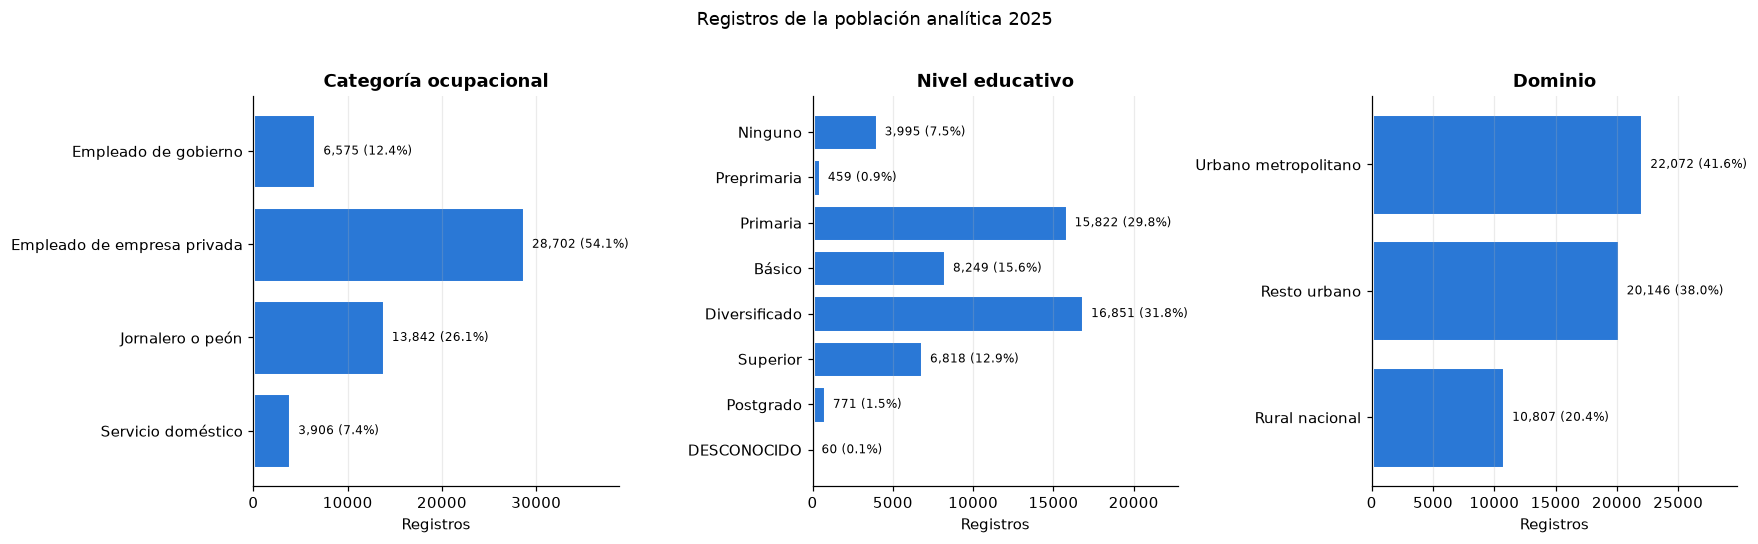

In [20]:
def conteo_categoria(df, cod, etiqueta):
    t = df.groupBy(cod, etiqueta).count().orderBy(cod).toPandas()
    t["pct"] = 100 * t["count"] / t["count"].sum()
    return t


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (cod, etiqueta, titulo) in zip(axes, [
    ("categoria_ocupacional_cod", "categoria_ocupacional", "Categoría ocupacional"),
    ("nivel_educativo_cod", "nivel_educativo", "Nivel educativo"),
    ("dominio_cod", "dominio", "Dominio"),
]):
    t = conteo_categoria(df25, cod, etiqueta)
    ax.barh(t[etiqueta], t["count"], color=AZUL, edgecolor="white", linewidth=2)
    ax.invert_yaxis()
    for y, (n, p) in enumerate(zip(t["count"], t["pct"])):
        ax.text(n, y, f"  {n:,} ({p:.1f}%)", va="center", fontsize=8)
    ax.set_title(titulo)
    ax.set_xlabel("Registros")
    ax.set_xlim(0, t["count"].max() * 1.35)
    ax.grid(axis="y", visible=False)
fig.suptitle("Registros de la población analítica 2025", y=1.02)
plt.tight_layout()
plt.show()

Las barras muestran los registros de la muestra analítica, no el número de trabajadores del país. Los empleados de empresa privada concentran la mayor parte de los registros. Los niveles educativos con más observaciones y el peso de cada dominio se leen en las etiquetas de cada barra. Las categorías con pocos registros darán estimaciones menos estables en las comparaciones por grupo y en los modelos.

### 2.2 Forma de la distribución del salario

El histograma de la izquierda usa escala lineal y muestra el rango hasta el percentil 99 para que la forma sea visible. El de la derecha usa el logaritmo base 10 del salario y cubre todos los registros. El objetivo de los modelos sigue siendo el salario en quetzales.

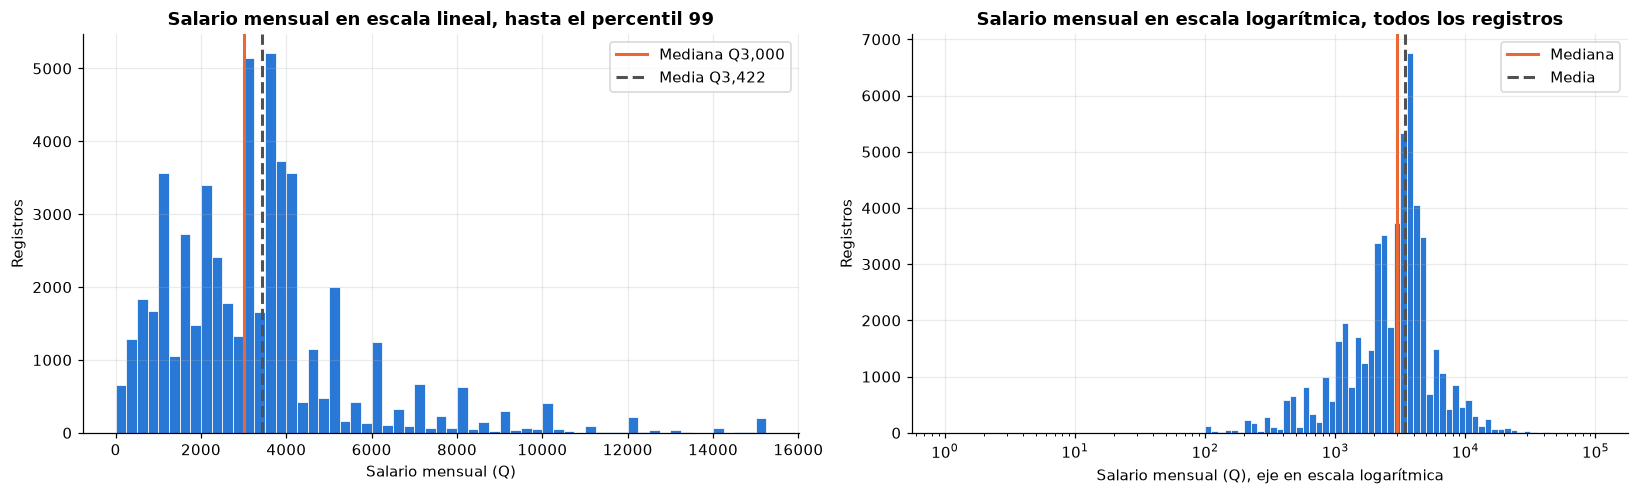

Coeficiente de asimetría del salario 6.00
La media supera a la mediana por Q422, es decir 14.1% por encima
Registros por encima del percentil 99 que no aparecen en el panel lineal 376


In [21]:
p99 = df25.agg(F.expr("percentile(salario_mensual, 0.99)")).first()[0]
media_sal = descriptivas.loc["Salario mensual (Q)", "media"]
mediana_sal = descriptivas.loc["Salario mensual (Q)", "mediana"]

ancho_lin = p99 / 60
hist_lin = (df25.filter(F.col("salario_mensual") <= p99)
            .groupBy(F.floor(F.col("salario_mensual") / ancho_lin).alias("b")).count().orderBy("b").toPandas())
ancho_log = 0.05
hist_log = (df25.groupBy(F.floor(F.log10("salario_mensual") / ancho_log).alias("b")).count().orderBy("b").toPandas())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
ax.bar(hist_lin["b"] * ancho_lin, hist_lin["count"], width=ancho_lin, align="edge", color=AZUL, edgecolor="white", linewidth=0.5)
ax.axvline(mediana_sal, color=NARANJA, lw=2, label=f"Mediana Q{mediana_sal:,.0f}")
ax.axvline(media_sal, color="#52514e", lw=2, ls="--", label=f"Media Q{media_sal:,.0f}")
ax.set_title("Salario mensual en escala lineal, hasta el percentil 99")
ax.set_xlabel("Salario mensual (Q)")
ax.set_ylabel("Registros")
ax.legend()

ax = axes[1]
ax.bar(10 ** (hist_log["b"] * ancho_log), hist_log["count"],
       width=10 ** ((hist_log["b"] + 1) * ancho_log) - 10 ** (hist_log["b"] * ancho_log),
       align="edge", color=AZUL, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.axvline(mediana_sal, color=NARANJA, lw=2, label="Mediana")
ax.axvline(media_sal, color="#52514e", lw=2, ls="--", label="Media")
ax.set_title("Salario mensual en escala logarítmica, todos los registros")
ax.set_xlabel("Salario mensual (Q), eje en escala logarítmica")
ax.set_ylabel("Registros")
ax.legend()
plt.tight_layout()
plt.show()

asim = descriptivas.loc["Salario mensual (Q)", "asimetria"]
print(f"Coeficiente de asimetría del salario {asim:.2f}")
print(f"La media supera a la mediana por Q{media_sal - mediana_sal:,.0f}, "
      f"es decir {100 * (media_sal / mediana_sal - 1):.1f}% por encima")
print(f"Registros por encima del percentil 99 que no aparecen en el panel lineal "
      f"{df25.filter(F.col('salario_mensual') > p99).count():,}")

**¿El salario presenta una distribución simétrica o asimétrica?**

Es asimétrica con cola a la derecha. La mayoría de registros se concentra en salarios bajos y medios y un grupo pequeño llega a valores varias veces más altos. El coeficiente de asimetría impreso arriba es positivo. En escala logarítmica la forma se acerca más a una campana, lo que indica que las diferencias relativas son más estables que las absolutas.

**¿Qué diferencia existe entre su media y su mediana?**

La media queda por encima de la mediana porque los salarios altos la jalan hacia la derecha. La mediana representa mejor el salario de un registro típico. Para los modelos esto importa porque RMSE da más peso a los errores en esos salarios altos, que se conservan en la base según las instrucciones.

### 2.3 Salario mediano por nivel educativo y por categoría ocupacional

Cada caja va del percentil 25 al 75, la línea interna es la mediana y los bigotes llegan a los percentiles 10 y 90. Todos los percentiles se calculan en Spark sobre la base completa.

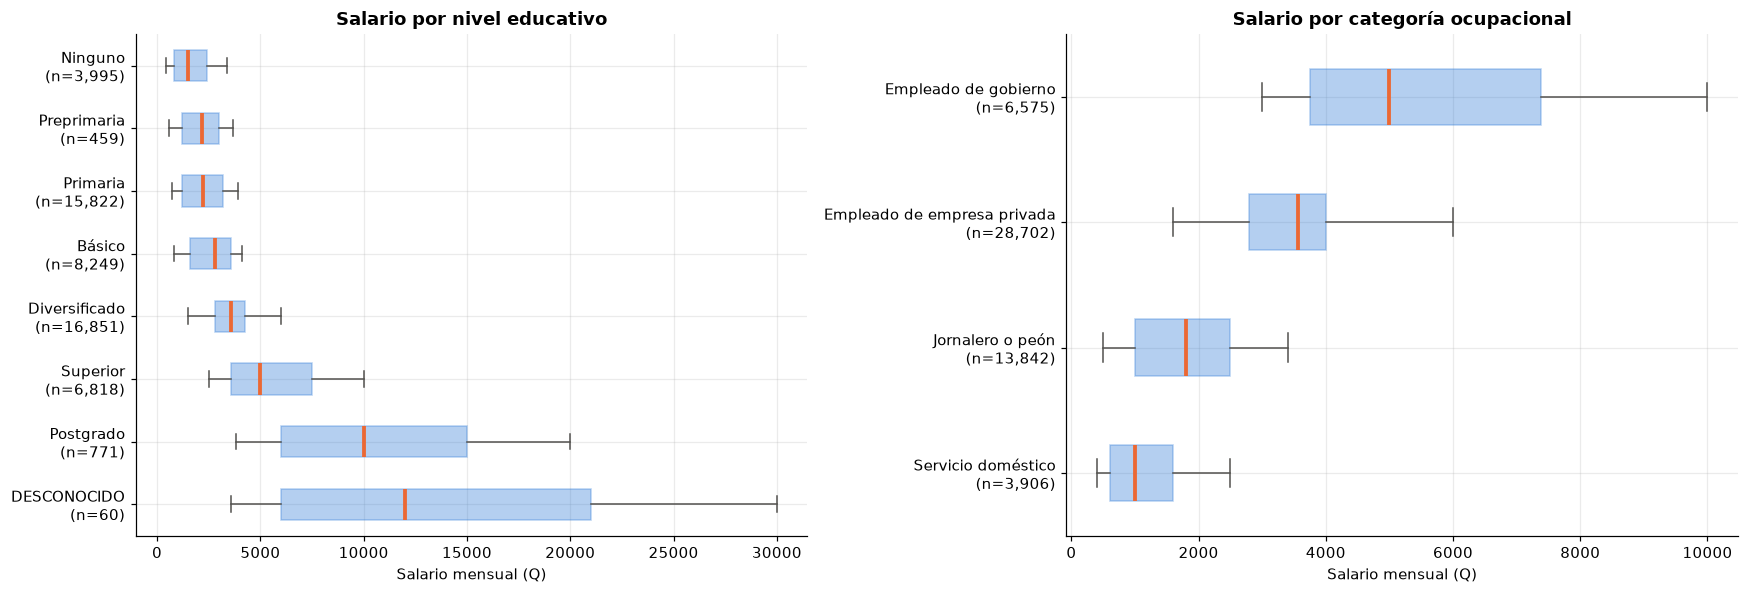

,nivel_educativo,n,media,mediana
0,Ninguno,3995,"1,767.09","1,500.00"
1,Preprimaria,459,"2,241.90","2,160.00"
2,Primaria,15822,"2,307.96","2,200.00"
3,Básico,8249,"2,730.20","2,800.00"
4,Diversificado,16851,"3,796.41","3,600.00"
5,Superior,6818,"5,965.30","5,000.00"
6,Postgrado,771,"11,409.27","10,000.00"
7,DESCONOCIDO,60,"14,452.27","12,000.00"


,categoria_ocupacional,n,media,mediana
0,Empleado de gobierno,6575,"5,971.53","5,000.00"
1,Empleado de empresa privada,28702,"3,875.14","3,567.50"
2,Jornalero o peón,13842,"1,878.61","1,800.00"
3,Servicio doméstico,3906,"1,265.74","1,000.00"


In [22]:
def percentiles_por_grupo(df, cod, etiqueta):
    return (df.groupBy(cod, etiqueta)
            .agg(F.count("*").alias("n"), F.mean("salario_mensual").alias("media"),
                 F.expr("percentile(salario_mensual, array(0.10, 0.25, 0.5, 0.75, 0.90))").alias("p"))
            .orderBy(cod).toPandas())


def cajas(ax, t, etiqueta, titulo):
    stats = [{"label": f"{e}\n(n={n:,})", "whislo": p[0], "q1": p[1], "med": p[2], "q3": p[3], "whishi": p[4]}
             for e, n, p in zip(t[etiqueta], t["n"], t["p"])]
    ax.bxp(stats, showfliers=False, vert=False, patch_artist=True,
           boxprops={"facecolor": AZUL, "alpha": 0.35, "edgecolor": AZUL},
           medianprops={"color": NARANJA, "linewidth": 2.5},
           whiskerprops={"color": "#52514e"}, capprops={"color": "#52514e"})
    ax.invert_yaxis()
    ax.set_title(titulo)
    ax.set_xlabel("Salario mensual (Q)")


t_nivel = percentiles_por_grupo(df25, "nivel_educativo_cod", "nivel_educativo")
t_cat = percentiles_por_grupo(df25, "categoria_ocupacional_cod", "categoria_ocupacional")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
cajas(axes[0], t_nivel, "nivel_educativo", "Salario por nivel educativo")
cajas(axes[1], t_cat, "categoria_ocupacional", "Salario por categoría ocupacional")
plt.tight_layout()
plt.show()

for t, etiqueta in [(t_nivel, "nivel_educativo"), (t_cat, "categoria_ocupacional")]:
    t = t.assign(mediana=t["p"].str[2])[[etiqueta, "n", "media", "mediana"]]
    display(t)

El salario mediano sube con el nivel educativo. Los registros con educación superior o postgrado tienen medianas mayores que los de ninguno o primaria, y también una dispersión mayor. Entre categorías ocupacionales, el empleo de gobierno muestra la mediana más alta y el servicio doméstico y los jornaleros las más bajas. Estas diferencias son asociaciones. No aíslan el efecto de la educación, porque la categoría, la edad y el dominio cambian al mismo tiempo. Las categorías con pocos registros, como DESCONOCIDO o postgrado, deben leerse con cuidado.

### 2.4 Tamaño de la muestra y salario mediano por trimestre

,periodo_archivo,n,media,mediana,variacion_mediana_pct
0,2025T1,13419,"3,315.63","3,000.00",NaN
1,2025T2,13492,"3,364.57","3,000.00",0.00
2,2025T3,13450,"3,469.07","3,200.00",6.67
3,2025T4,12664,"3,544.57","3,200.00",0.00


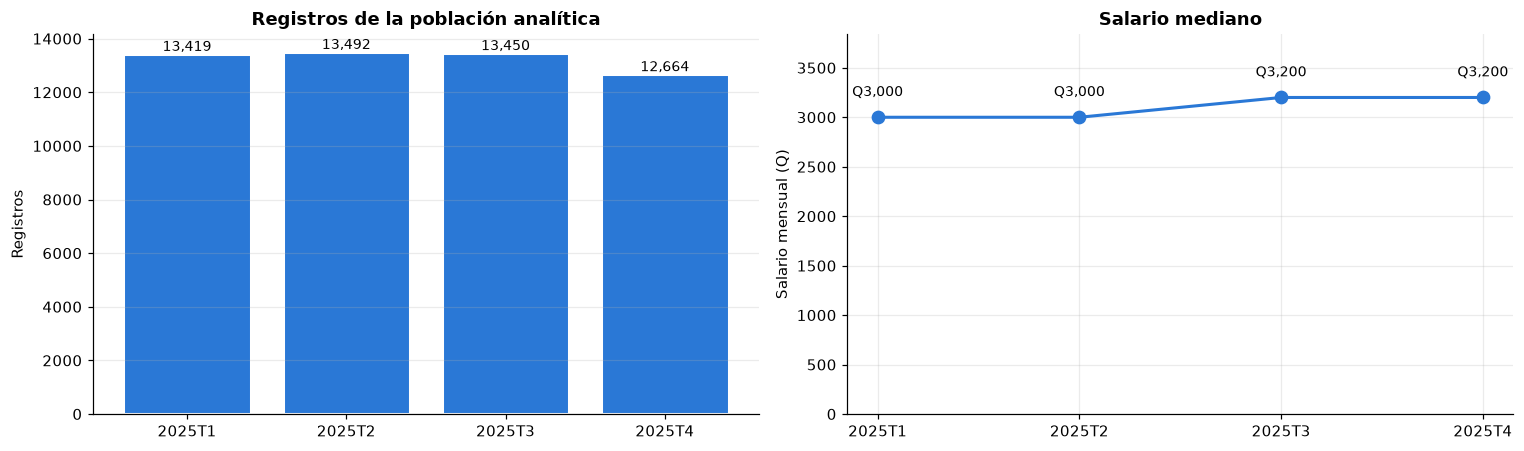

In [23]:
por_trimestre = (df25.groupBy("periodo_archivo")
                 .agg(F.count("*").alias("n"), F.mean("salario_mensual").alias("media"),
                      F.expr("percentile(salario_mensual, 0.5)").alias("mediana"))
                 .orderBy("periodo_archivo").toPandas())
por_trimestre["variacion_mediana_pct"] = 100 * por_trimestre["mediana"].pct_change()
display(por_trimestre)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(por_trimestre["periodo_archivo"], por_trimestre["n"], color=AZUL, edgecolor="white", linewidth=2)
for x, n in enumerate(por_trimestre["n"]):
    axes[0].text(x, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Registros de la población analítica")
axes[0].set_ylabel("Registros")
axes[0].grid(axis="x", visible=False)

axes[1].plot(por_trimestre["periodo_archivo"], por_trimestre["mediana"], marker="o", color=AZUL, lw=2, ms=8)
for x, m in enumerate(por_trimestre["mediana"]):
    axes[1].text(x, m, f"Q{m:,.0f}\n", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Salario mediano")
axes[1].set_ylabel("Salario mensual (Q)")
axes[1].set_ylim(0, por_trimestre["mediana"].max() * 1.2)
plt.tight_layout()
plt.show()

El número de registros cambia entre trimestres porque cambian el tamaño de cada archivo y la cantidad de asalariados con datos válidos. La tabla muestra la variación de la mediana entre trimestres. Un cambio pequeño en la mediana puede deberse a la rotación de la muestra y no necesariamente a un cambio en los salarios. Como las cifras no están ponderadas, no deben leerse como la evolución del salario en el país.

## 3. Relaciones entre variables numéricas

La correlación de Pearson se calcula con `VectorAssembler` y `Correlation.corr()` sobre todos los registros elegibles de 2025.

In [24]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQUETAS_CORR = ["Salario", "Edad", "Antigüedad", "Horas"]

vector_corr = VectorAssembler(inputCols=VARS_CORR, outputCol="vars").transform(df25).select("vars")
pearson = Correlation.corr(vector_corr, "vars", "pearson").first()[0].toArray()
spearman = Correlation.corr(vector_corr, "vars", "spearman").first()[0].toArray()

matriz_pearson = pd.DataFrame(pearson, index=ETIQUETAS_CORR, columns=ETIQUETAS_CORR)
matriz_spearman = pd.DataFrame(spearman, index=ETIQUETAS_CORR, columns=ETIQUETAS_CORR)
print("Matriz de correlación de Pearson")
display(matriz_pearson.round(3))
print("Matriz de correlación de Spearman")
display(matriz_spearman.round(3))

Matriz de correlación de Pearson


,Salario,Edad,Antigüedad,Horas
Salario,1.00,0.15,0.18,0.08
Edad,0.15,1.00,0.49,-0.10
Antigüedad,0.18,0.49,1.00,-0.06
Horas,0.08,-0.10,-0.06,1.00


Matriz de correlación de Spearman


,Salario,Edad,Antigüedad,Horas
Salario,1.00,0.15,0.26,0.14
Edad,0.15,1.00,0.42,-0.12
Antigüedad,0.26,0.42,1.00,-0.05
Horas,0.14,-0.12,-0.05,1.00


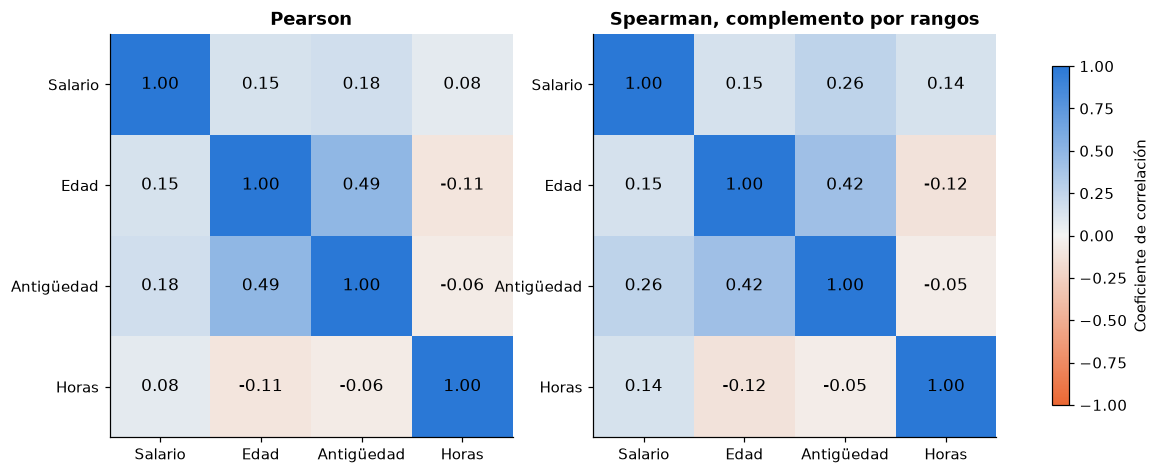

Correlación de Pearson con el salario, de mayor a menor en valor absoluto
   Antigüedad 0.180
   Edad 0.147
   Horas 0.076
Correlación entre edad y antigüedad 0.487


In [25]:
from matplotlib.colors import LinearSegmentedColormap

divergente = LinearSegmentedColormap.from_list("div", ["#eb6834", "#f4f4f2", "#2a78d6"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, matriz, titulo in [(axes[0], matriz_pearson, "Pearson"), (axes[1], matriz_spearman, "Spearman, complemento por rangos")]:
    im = ax.imshow(matriz.values, cmap=divergente, vmin=-1, vmax=1)
    ax.set_xticks(range(4), matriz.columns)
    ax.set_yticks(range(4), matriz.index)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{matriz.values[i, j]:.2f}", ha="center", va="center", fontsize=11)
    ax.set_title(titulo)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="Coeficiente de correlación")
plt.show()

corr_sal = matriz_pearson["Salario"].drop("Salario").sort_values(key=abs, ascending=False)
print("Correlación de Pearson con el salario, de mayor a menor en valor absoluto")
for v, r in corr_sal.items():
    print(f"   {v} {r:.3f}")
print(f"Correlación entre edad y antigüedad {matriz_pearson.loc['Edad', 'Antigüedad']:.3f}")

**¿Qué variables presentan mayor asociación lineal con el salario?**

El listado impreso ordena las variables por el valor absoluto de su correlación con el salario. Las tres correlaciones con el salario son bajas, todas menores de 0.2. La antigüedad, 0.18, y la edad, 0.15, quedan por encima de las horas, 0.08. Ninguna variable numérica por sí sola explica una parte grande de la variación del salario. Parte de la razón es la cola derecha del salario, porque Pearson se ve afectado por los valores extremos. La matriz de Spearman usa rangos y es menos sensible a ellos. Aquí Spearman es mayor que Pearson para la antigüedad, 0.26 frente a 0.18, y para las horas, 0.14 frente a 0.08, y es igual para la edad, 0.15. Esa diferencia indica que la relación con el salario es monótona pero no lineal, y que los valores extremos reducen la correlación de Pearson. Esto anticipa que las variables categóricas como educación y categoría ocupacional serán necesarias en los modelos.

**¿Existe relación entre edad y antigüedad?**

Sí. La correlación es positiva y moderada, 0.49. Una persona mayor ha tenido más tiempo para acumular años en su empleo, y la antigüedad nunca puede superar a la edad por el filtro aplicado. La relación no es perfecta porque muchas personas cambian de empleo y reinician su antigüedad. Esta asociación también indica que las dos variables comparten información en los modelos lineales.

## 4. Segmentación de perfiles con KMeans

### 4.1 Variables y decisión sobre el salario

La segmentación busca perfiles laborales de los asalariados. Las variables base son edad, antigüedad y horas habituales por semana. Se comparan tres variantes para decidir si vale la pena incluir el salario.

- Sin salario, con edad, antigüedad y horas
- Con el salario en quetzales
- Con el logaritmo base 10 del salario

Todas las variables se estandarizan con `StandardScaler` para que ninguna domine por su escala. Para cada variante se prueban K de 2 a 5 con semilla fija. Se registran la silueta, calculada con `ClusteringEvaluator` sobre todos los registros, la suma de distancias al centroide y el tamaño del grupo más pequeño.

In [26]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

df_km = df25.withColumn("log_salario", F.log10("salario_mensual")).cache()
n_km = df_km.count()

BASE_KM = ["edad", "antiguedad", "horas_semanales"]
VARIANTES = {
    "sin_salario": BASE_KM,
    "con_salario": BASE_KM + ["salario_mensual"],
    "con_log_salario": BASE_KM + ["log_salario"],
}
VALORES_K = [2, 3, 4, 5]
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")


def pipeline_kmeans(variables, k):
    return Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol="vars_km"),
        StandardScaler(inputCol="vars_km", outputCol="features", withMean=True, withStd=True),
        KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=SEMILLA, maxIter=50),
    ])


resultados_km, modelos_km = [], {}
for variante, variables in VARIANTES.items():
    for k in VALORES_K:
        modelo = pipeline_kmeans(variables, k).fit(df_km)
        pred = modelo.transform(df_km)
        resumen = modelo.stages[-1].summary
        resultados_km.append({
            "variante": variante, "k": k,
            "silueta": evaluador.evaluate(pred),
            "wssse": resumen.trainingCost,
            "pct_grupo_menor": 100 * min(resumen.clusterSizes) / n_km,
        })
        modelos_km[(variante, k)] = modelo

resultados_km = pd.DataFrame(resultados_km)
resultados_km.pivot(index="k", columns="variante", values=["silueta", "pct_grupo_menor"])

silueta                         pct_grupo_menor                        
variante con_log_salario con_salario sin_salario con_log_salario con_salario sin_salario
k                                                                                       
2                   0.47        0.51        0.55           28.27       27.03       27.51
3                   0.48        0.34        0.42           17.60       16.76       14.48
4                   0.37        0.34        0.48           11.54       13.67       12.95
5                   0.40        0.38        0.48           12.58        3.95       11.65

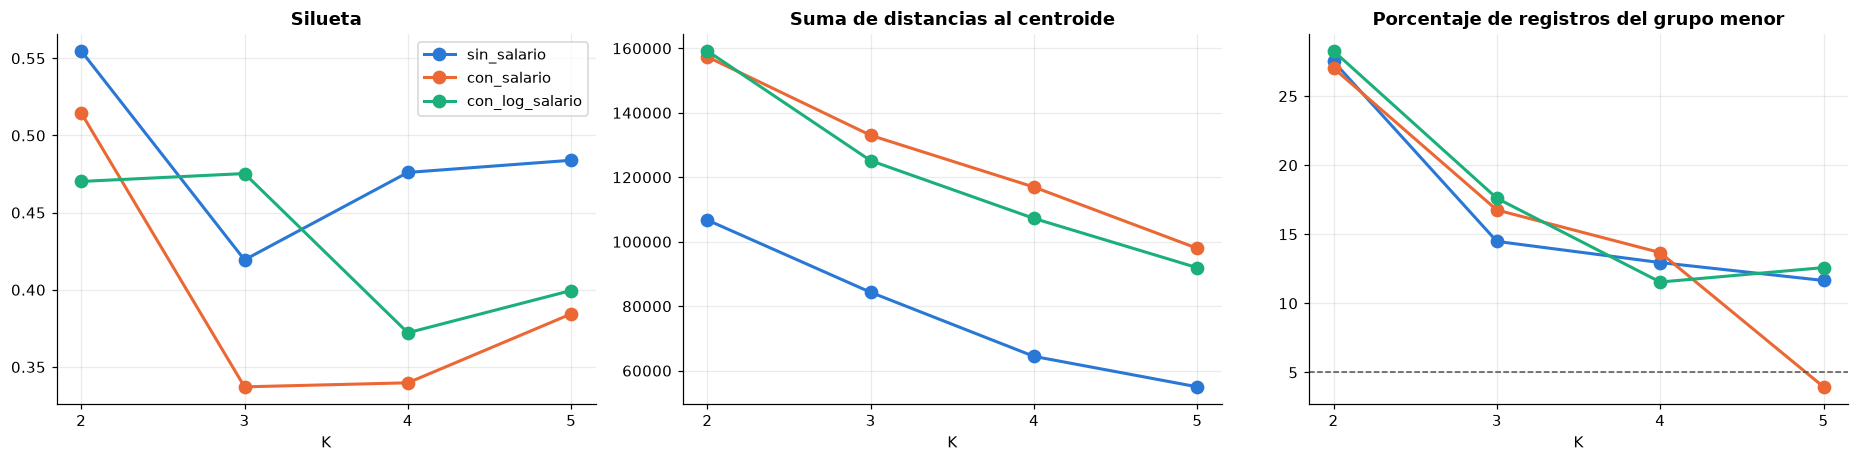

con_salario K=2 tamaños de grupo [14331, 38694]
con_salario K=3 tamaños de grupo [8885, 16773, 27367]
con_salario K=4 tamaños de grupo [7250, 8571, 11800, 25404]
con_salario K=5 tamaños de grupo [2096, 6328, 8446, 11055, 25100]


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, metrica, titulo in [(axes[0], "silueta", "Silueta"), (axes[1], "wssse", "Suma de distancias al centroide"),
                            (axes[2], "pct_grupo_menor", "Porcentaje de registros del grupo menor")]:
    for color, (variante, t) in zip(COLORES, resultados_km.groupby("variante", sort=False)):
        ax.plot(t["k"], t[metrica], marker="o", lw=2, ms=8, color=color, label=variante)
    ax.set_xticks(VALORES_K)
    ax.set_xlabel("K")
    ax.set_title(titulo)
axes[0].legend()
axes[2].axhline(5, color="#52514e", ls="--", lw=1)
plt.tight_layout()
plt.show()

# Tamaño de los grupos con el salario en quetzales
for k in VALORES_K:
    tamanos = modelos_km[("con_salario", k)].stages[-1].summary.clusterSizes
    print(f"con_salario K={k} tamaños de grupo {sorted(tamanos)}")

**¿Vale la pena incluir el salario?**

Con el salario en quetzales la silueta no mejora. En K = 2 es de 0.51 frente a 0.55 sin salario, y en K = 3 y K = 4 baja a 0.34, frente a 0.42 y 0.48. Con K = 5 el grupo menor cae a 3.95 % de los registros, por debajo del umbral de 5 %, lo que indica que KMeans empieza a aislar un grupo pequeño de salarios extremos. El salario tiene cola derecha larga y en quetzales domina la distancia. Con el logaritmo del salario los valores extremos pesan menos, pero la silueta tampoco supera a la variante sin salario, 0.47 en K = 2 y 0.48 en K = 3.

El equipo decide no incluir el salario en la segmentación. Las razones son tres.

- El objetivo es describir perfiles por características laborales observadas, y el salario es la variable que luego se quiere estimar.
- El salario extremo distorsiona los centroides, y aplicar una transformación solo para el clustering cambiaría la escala del objetivo.
- Dejarlo fuera permite usar el salario como variable de descripción y comparar cuánto ganan los perfiles formados con otras variables.

La etiqueta de cluster no se usará como predictor en los modelos supervisados.

### 4.2 Elección de K

El criterio del grupo es elegir, dentro de la variante sin salario, el K con mayor silueta entre los que dejan cada grupo con al menos 5% de los registros. La regla evita grupos demasiado pequeños para describir un perfil. Si el equipo prefiere otro K por interpretación, puede fijarlo en `K_MANUAL`.

In [28]:
K_MANUAL = None
VARIANTE_ELEGIDA = "sin_salario"

candidatos = resultados_km[(resultados_km["variante"] == VARIANTE_ELEGIDA) & (resultados_km["pct_grupo_menor"] >= 5)]
if candidatos.empty:
    candidatos = resultados_km[resultados_km["variante"] == VARIANTE_ELEGIDA]
K_ELEGIDO = K_MANUAL or int(candidatos.sort_values("silueta", ascending=False).iloc[0]["k"])
display(resultados_km[resultados_km["variante"] == VARIANTE_ELEGIDA].set_index("k"))
print(f"K elegido {K_ELEGIDO}")

modelo_final = modelos_km[(VARIANTE_ELEGIDA, K_ELEGIDO)]
segmentos = modelo_final.transform(df_km).select(*df_km.columns, "cluster").cache()

,variante,silueta,wssse,pct_grupo_menor
k,,,,
2,sin_salario,0.55,"106,717.39",27.51
3,sin_salario,0.42,"84,311.43",14.48
4,sin_salario,0.48,"64,438.21",12.95
5,sin_salario,0.48,"54,990.35",11.65


K elegido 2


### 4.3 Perfil de cada cluster

Los centroides se reportan en unidades originales. Se calculan con todos los registros de cada grupo, junto con el salario y la composición por categoría, educación y dominio. La descripción de cada grupo se arma a partir de estos valores.

In [29]:
perfil = (segmentos.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.mean("edad").alias("edad_media"),
    F.mean("antiguedad").alias("antiguedad_media"),
    F.expr("percentile(antiguedad, 0.5)").alias("antiguedad_mediana"),
    F.mean("horas_semanales").alias("horas_media"),
    F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
    F.mean("salario_mensual").alias("salario_medio"),
).orderBy("cluster").toPandas().set_index("cluster"))
perfil["pct_registros"] = 100 * perfil["n"] / perfil["n"].sum()


def composicion(col):
    t = segmentos.groupBy("cluster", col).count().toPandas()
    t = t.pivot(index="cluster", columns=col, values="count").fillna(0)
    return 100 * t.div(t.sum(axis=1), axis=0)


comp_categoria = composicion("categoria_ocupacional")
comp_nivel = composicion("nivel_educativo")
comp_dominio = composicion("dominio")


def describir(fila, c):
    edad = "jóvenes" if fila.edad_media < 30 else ("adultos" if fila.edad_media < 45 else "adultos mayores")
    ant = ("poca antigüedad" if fila.antiguedad_mediana < 2 else
           ("antigüedad media" if fila.antiguedad_mediana < 8 else "antigüedad alta"))
    horas = ("jornada parcial" if fila.horas_media < 30 else
             ("jornada completa" if fila.horas_media <= 48 else "jornada extendida"))
    cat = comp_categoria.loc[c].idxmax()
    niv = comp_nivel.loc[c].idxmax()
    return (f"{edad.capitalize()} con {ant} y {horas}. Predomina {cat.lower()} "
            f"({comp_categoria.loc[c].max():.0f}%) y nivel {niv.lower()} ({comp_nivel.loc[c].max():.0f}%)")


perfil["descripcion"] = [describir(fila, c) for c, fila in perfil.iterrows()]
display(perfil)
print("Composición por categoría ocupacional (% del cluster)")
display(comp_categoria.round(1))
print("Composición por nivel educativo (% del cluster)")
display(comp_nivel.round(1))
print("Composición por dominio (% del cluster)")
display(comp_dominio.round(1))

,n,edad_media,antiguedad_media,antiguedad_mediana,horas_media,salario_mediano,salario_medio,pct_registros,descripcion
cluster,,,,,,,,,
0,14586,51.29,13.82,13.00,41.31,"3,468.00","4,069.99",27.51,Adultos mayores con antigüedad alta y jornada completa. Predomina empleado de empresa privada (43%) y nivel primaria (33%)
1,38439,29.08,2.42,1.33,48.21,"3,000.00","3,175.68",72.49,Jóvenes con poca antigüedad y jornada extendida. Predomina empleado de empresa privada (59%) y nivel diversificado (35%)


Composición por categoría ocupacional (% del cluster)


categoria_ocupacional,Empleado de empresa privada,Empleado de gobierno,Jornalero o peón,Servicio doméstico
cluster,,,,
0,42.50,23.50,24.30,9.60
1,58.50,8.20,26.80,6.50


Composición por nivel educativo (% del cluster)


nivel_educativo,Básico,DESCONOCIDO,Diversificado,Ninguno,Postgrado,Preprimaria,Primaria,Superior
cluster,,,,,,,,
0,9.60,0.30,22.50,14.50,2.40,1.20,32.50,17.10
1,17.80,0.00,35.30,4.90,1.10,0.80,28.80,11.30


Composición por dominio (% del cluster)


dominio,Resto urbano,Rural nacional,Urbano metropolitano
cluster,,,
0,37.50,17.00,45.50
1,38.20,21.70,40.20


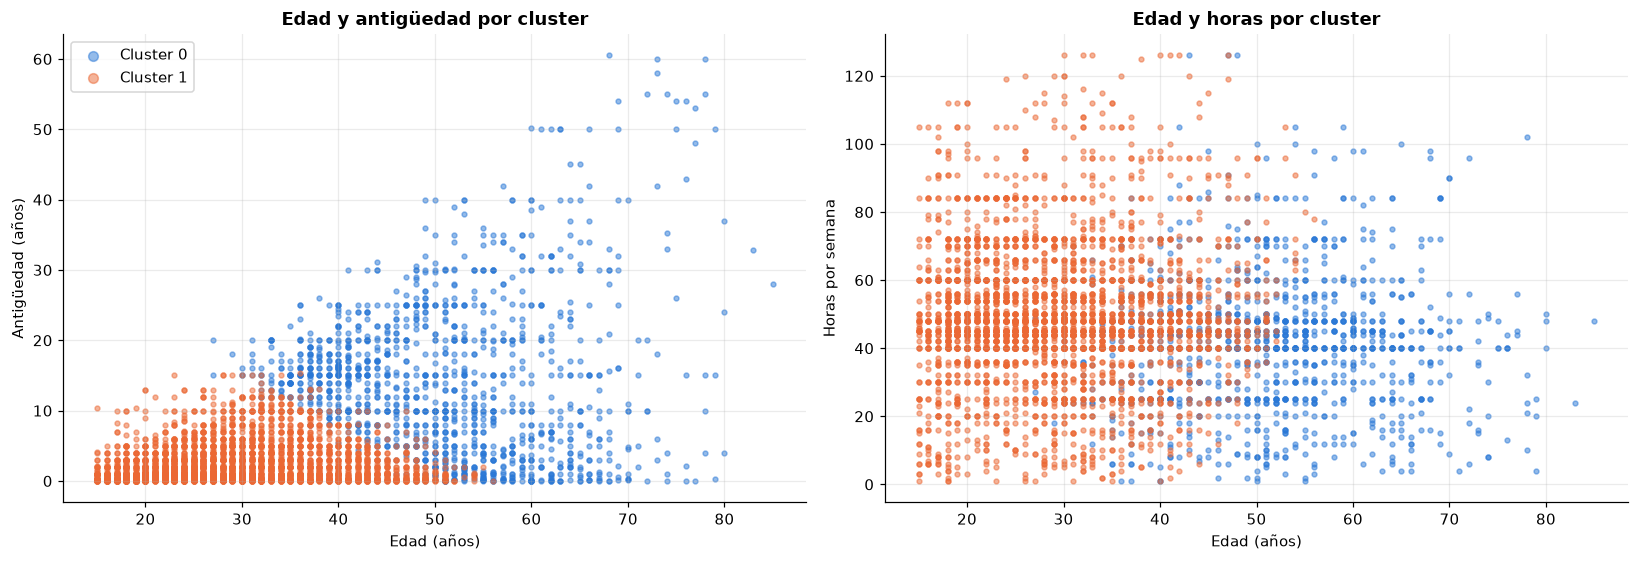

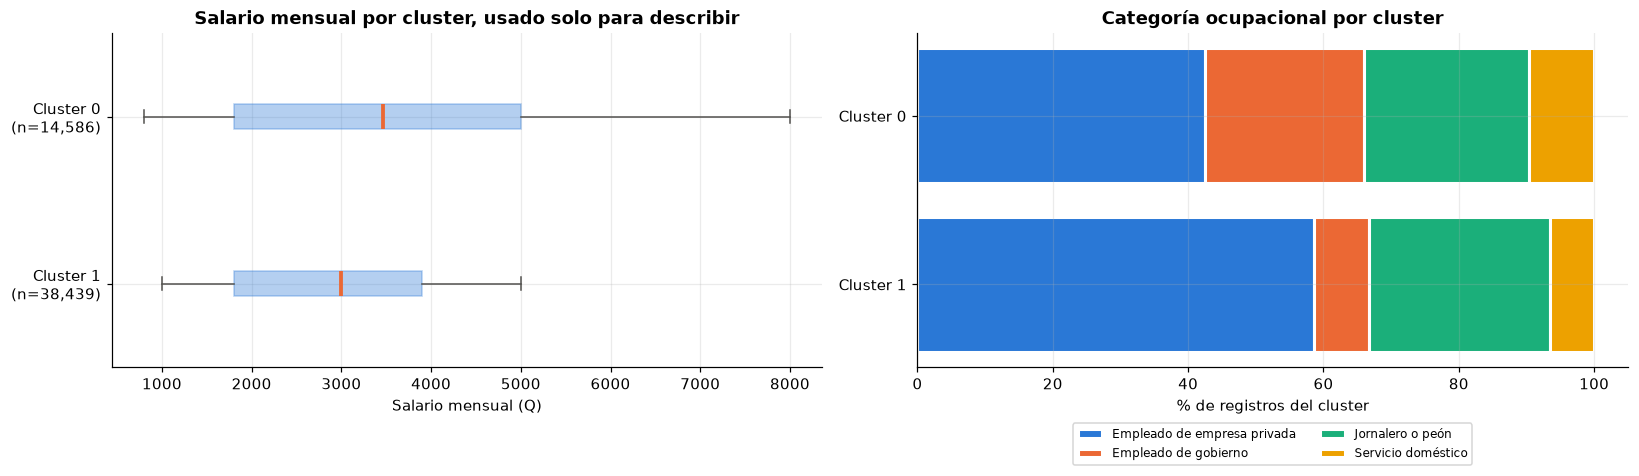

In [30]:
# Muestra de hasta 5,000 registros solo para dibujar
fraccion = min(1.0, 6000 / segmentos.count())
muestra = segmentos.sample(fraction=fraccion, seed=SEMILLA).limit(5000).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for c in sorted(muestra["cluster"].unique()):
    m = muestra[muestra["cluster"] == c]
    axes[0].scatter(m["edad"], m["antiguedad"], s=10, alpha=0.5, color=COLORES[c], label=f"Cluster {c}")
    axes[1].scatter(m["edad"], m["horas_semanales"], s=10, alpha=0.5, color=COLORES[c], label=f"Cluster {c}")
axes[0].set(xlabel="Edad (años)", ylabel="Antigüedad (años)", title="Edad y antigüedad por cluster")
axes[1].set(xlabel="Edad (años)", ylabel="Horas por semana", title="Edad y horas por cluster")
axes[0].legend(markerscale=2)
plt.tight_layout()
plt.show()

cajas_cluster = (segmentos.groupBy("cluster")
                 .agg(F.count("*").alias("n"),
                      F.expr("percentile(salario_mensual, array(0.10, 0.25, 0.5, 0.75, 0.90))").alias("p"))
                 .orderBy("cluster").toPandas())
cajas_cluster["cluster"] = "Cluster " + cajas_cluster["cluster"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
cajas(axes[0], cajas_cluster, "cluster", "Salario mensual por cluster, usado solo para describir")
izq = np.zeros(len(comp_categoria))
for color, cat in zip(COLORES, comp_categoria.columns):
    axes[1].barh([f"Cluster {c}" for c in comp_categoria.index], comp_categoria[cat], left=izq,
                 color=color, edgecolor="white", linewidth=2, label=cat)
    izq += comp_categoria[cat].values
axes[1].invert_yaxis()
axes[1].set_xlabel("% de registros del cluster")
axes[1].set_title("Categoría ocupacional por cluster")
axes[1].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

### 4.4 Interpretación

Cada cluster tiene una descripción automática en la tabla de perfiles, construida con umbrales fijos. Edad menor de 30 se toma como joven, de 30 a 44 como adulto y de 45 en adelante como adulto mayor. Antigüedad menor de 2 años se toma como poca, de 2 a 7 como media y de 8 en adelante como alta. Menos de 30 horas se toma como jornada parcial, de 30 a 48 como completa y más de 48 como extendida. La edad y las horas se clasifican con la media del grupo y la antigüedad con su mediana, porque la antigüedad tiene cola derecha y la media exagera la antigüedad típica.

Los perfiles se separan sobre todo por edad y antigüedad, que están correlacionadas, y por horas. El salario no participó en la formación de los grupos, pero su mediana cambia entre ellos. Los grupos con más antigüedad suelen tener salarios medianos más altos y una mayor presencia de empleo de gobierno. Los grupos jóvenes con poca antigüedad concentran más empleo privado y salarios menores. La jornada extendida del grupo joven, 48 horas frente a 41, no se concentra en servicio doméstico ni en jornaleros. Ese grupo tiene 6.5 % de servicio doméstico y 26.8 % de jornaleros, frente a 9.6 % y 24.3 % en el otro. Su rasgo más marcado es la mayor proporción de empleo privado, 58.5 % frente a 42.5 %.

La silueta de la segmentación elegida es moderada. Los grupos no están separados de forma nítida y los perfiles se deben leer como tendencias, no como tipos cerrados de trabajador. El análisis es no ponderado y describe los registros de 2025.

## 5. Pipeline de regresión lineal

A partir de aquí la tarea es estimar `salario_mensual` con los seis predictores que indica el enunciado: edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio. Se estima el salario del período observado. No es un pronóstico del salario futuro de una persona.

No entran como predictores los identificadores, el factor de expansión, otros montos de ingreso, el salario por hora ni la etiqueta de cluster de la sección 4.

### 5.1 Partición de entrenamiento y validación

La partición sigue el uso que el enunciado asigna a cada archivo. Los trimestres I, II y III de 2025 forman el conjunto de entrenamiento. El trimestre IV de 2025 queda como conjunto de validación y sirve para elegir la configuración de cada algoritmo. El primer trimestre de 2026 no se usa en esta sección ni en la siguiente.

La partición es por período y no aleatoria. La encuesta tiene diseño longitudinal con rotación, así que una misma persona puede aparecer en más de un trimestre. Una partición aleatoria sobre la unión de los cuatro archivos pondría registros de la misma persona a ambos lados y la validación quedaría optimista. Separar por trimestre reproduce además el uso previsto del modelo: ajustar con trimestres anteriores y medir sobre un trimestre posterior.

In [31]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

OBJETIVO = "salario_mensual"
NUMERICAS = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
PREDICTORES = NUMERICAS + CATEGORICAS

PERIODOS_ENTRENAMIENTO = ["2025T1", "2025T2", "2025T3"]
PERIODOS_VALIDACION = ["2025T4"]

columnas_modelo = [OBJETIVO] + PREDICTORES + ["periodo_archivo"]
entrenamiento = df25.filter(F.col("periodo_archivo").isin(PERIODOS_ENTRENAMIENTO)).select(*columnas_modelo).cache()
validacion = df25.filter(F.col("periodo_archivo").isin(PERIODOS_VALIDACION)).select(*columnas_modelo).cache()

n_entrenamiento, n_validacion = entrenamiento.count(), validacion.count()
print(f"Entrenamiento {n_entrenamiento:,} registros de {', '.join(PERIODOS_ENTRENAMIENTO)}")
print(f"Validación    {n_validacion:,} registros de {', '.join(PERIODOS_VALIDACION)}")
print(f"Suma {n_entrenamiento + n_validacion:,} contra {df25.count():,} registros de la base preparada de 2025")

reparto = (df25.groupBy("periodo_archivo").agg(
    F.count("*").alias("n"),
    F.mean(OBJETIVO).alias("salario_medio"),
    F.expr(f"percentile({OBJETIVO}, 0.5)").alias("salario_mediano"),
).orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
reparto["uso"] = ["Entrenamiento" if p in PERIODOS_ENTRENAMIENTO else "Validación" for p in reparto.index]
reparto

Entrenamiento 40,361 registros de 2025T1, 2025T2, 2025T3
Validación    12,664 registros de 2025T4
Suma 53,025 contra 53,025 registros de la base preparada de 2025


,n,salario_medio,salario_mediano,uso
periodo_archivo,,,,
2025T1,13419,"3,315.63","3,000.00",Entrenamiento
2025T2,13492,"3,364.57","3,000.00",Entrenamiento
2025T3,13450,"3,469.07","3,200.00",Entrenamiento
2025T4,12664,"3,544.57","3,200.00",Validación


El trimestre de validación tiene un salario medio y un salario mediano del mismo orden que los trimestres de entrenamiento, según la tabla anterior. Eso indica que la diferencia entre entrenamiento y validación no viene de un cambio de nivel del salario entre cortes.

### 5.2 Modelo de referencia

El modelo de referencia predice una constante para todos los registros. Se reportan dos constantes calculadas sobre el conjunto de entrenamiento: la media y la mediana del salario. La media es la constante que minimiza el RMSE y la mediana es la que minimiza el MAE, de modo que cada métrica tiene su punto de comparación. Un modelo con predictores aporta solo si queda por debajo de estas cifras.

Las tres métricas se calculan con `RegressionEvaluator` sobre el conjunto completo que corresponde en cada caso.

In [32]:
def metricas(predicciones):
    # MAE, RMSE y R2 sobre el conjunto completo que recibe la función
    pred = predicciones.select(OBJETIVO, "prediction").cache()
    try:
        return {
            nombre: RegressionEvaluator(labelCol=OBJETIVO, predictionCol="prediction", metricName=clave).evaluate(pred)
            for nombre, clave in [("MAE", "mae"), ("RMSE", "rmse"), ("R2", "r2")]
        }
    finally:
        pred.unpersist()


media_entrenamiento = entrenamiento.agg(F.mean(OBJETIVO)).first()[0]
mediana_entrenamiento = entrenamiento.agg(F.expr(f"percentile({OBJETIVO}, 0.5)")).first()[0]


def prediccion_constante(df, valor):
    return df.withColumn("prediction", F.lit(float(valor)))


REFERENCIAS = {
    f"Referencia media Q{media_entrenamiento:,.0f}": media_entrenamiento,
    f"Referencia mediana Q{mediana_entrenamiento:,.0f}": mediana_entrenamiento,
}
referencias = pd.DataFrame([
    {"modelo": nombre, **metricas(prediccion_constante(validacion, valor))}
    for nombre, valor in REFERENCIAS.items()
]).set_index("modelo")
print("Métricas sobre el trimestre de validación")
referencias

Métricas sobre el trimestre de validación


,MAE,RMSE,R2
modelo,,,
"Referencia media Q3,383","1,672.50","2,889.57",-0.00
"Referencia mediana Q3,000","1,670.39","2,936.00",-0.04


El R² de la referencia de media queda cerca de cero porque esa constante casi no aporta información sobre la variación del salario en validación. El valor puede ser levemente negativo si la media de entrenamiento no coincide con la media del trimestre de validación. La referencia de mediana tiene el MAE más bajo de las dos y un R² peor, lo que es esperable porque cada constante optimiza una métrica distinta.

### 5.3 Construcción del pipeline

El pipeline tiene cuatro bloques:

1. `StringIndexer` convierte nivel educativo, categoría ocupacional y dominio en índices numéricos. Se usa `handleInvalid="keep"` para que una categoría presente en validación o en 2026 pero ausente en entrenamiento reciba un índice propio en lugar de detener la ejecución. La categoría DESCONOCIDO entra como una más.
2. `OneHotEncoder` convierte esos índices en vectores indicadores con `dropLast=True`. Con `handleInvalid="keep"` el vector incluye además una columna reservada para categorías nuevas. Como muestra la lista de nombres de la celda siguiente, todas las categorías observadas conservan su propia columna, así que ninguna actúa como nivel de referencia. Las indicadoras de cada variable suman uno y quedan colineales con el intercepto. Las predicciones no se ven afectadas, pero los coeficientes de las indicadoras no se leen frente a una categoría base. Solo tiene sentido compararlos entre categorías de la misma variable.
3. `VectorAssembler` une las tres variables numéricas con los vectores indicadores en la columna `features`.
4. `LinearRegression` con `standardization=True`. La estandarización ocurre dentro del estimador, por eso no se agrega un `StandardScaler`. Los coeficientes se devuelven en la escala original de cada variable.

Todas las etapas se ajustan con `fit` sobre el conjunto de entrenamiento. Las categorías observadas, los índices y las medias y desviaciones de la estandarización salen solo de esos registros. La validación pasa por `transform` y no interviene en el ajuste.

In [33]:
def etapas_categoricas():
    # Las mismas etapas de preparación para la regresión lineal y para Random Forest
    indexadores = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAS]
    codificador = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in CATEGORICAS],
        outputCols=[f"{c}_ohe" for c in CATEGORICAS],
        dropLast=True, handleInvalid="keep",
    )
    ensamblador = VectorAssembler(
        inputCols=NUMERICAS + [f"{c}_ohe" for c in CATEGORICAS], outputCol="features", handleInvalid="error",
    )
    return indexadores + [codificador, ensamblador]


def nombres_features(modelo, df):
    # Los nombres salen de los metadatos de la columna features, así coinciden con el orden de los coeficientes
    atributos = modelo.transform(df.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]
    planos = [a for grupo in atributos.values() for a in grupo]
    return [a["name"] for a in sorted(planos, key=lambda a: a["idx"])]


ejemplo_features = Pipeline(stages=etapas_categoricas()).fit(entrenamiento)
NOMBRES_FEATURES = nombres_features(ejemplo_features, entrenamiento)
print(f"{len(NOMBRES_FEATURES)} columnas en el vector features")
print(NOMBRES_FEATURES)

21 columnas en el vector features
['edad', 'antiguedad', 'horas_semanales', 'nivel_educativo_ohe_Diversificado', 'nivel_educativo_ohe_Primaria', 'nivel_educativo_ohe_Básico', 'nivel_educativo_ohe_Superior', 'nivel_educativo_ohe_Ninguno', 'nivel_educativo_ohe_Postgrado', 'nivel_educativo_ohe_Preprimaria', 'nivel_educativo_ohe_DESCONOCIDO', 'nivel_educativo_ohe___unknown', 'categoria_ocupacional_ohe_Empleado de empresa privada', 'categoria_ocupacional_ohe_Jornalero o peón', 'categoria_ocupacional_ohe_Empleado de gobierno', 'categoria_ocupacional_ohe_Servicio doméstico', 'categoria_ocupacional_ohe___unknown', 'dominio_ohe_Urbano metropolitano', 'dominio_ohe_Resto urbano', 'dominio_ohe_Rural nacional', 'dominio_ohe___unknown']


En la lista impresa aparece un nombre terminado en `__unknown` por cada variable categórica. Es el espacio que reserva `handleInvalid="keep"` para una categoría que no estaba en entrenamiento. Mientras esa categoría no aparezca, la columna queda en cero y su coeficiente también.

### 5.4 Configuraciones de regularización

Se prueban seis configuraciones de `LinearRegression`. Todas se ajustan con los datos de entrenamiento y se miden sobre validación. `regParam` controla la fuerza de la penalización y `elasticNetParam` reparte esa penalización entre la norma L1 y la norma L2. Con `elasticNetParam` en 0 la penalización es de tipo ridge, en 1 es de tipo lasso y un valor intermedio mezcla ambas.

| Configuración | regParam | elasticNetParam | Tipo |
| --- | --- | --- | --- |
| lr1 | 0.0 | 0.0 | Mínimos cuadrados sin penalización |
| lr2 | 0.1 | 0.0 | Ridge suave |
| lr3 | 1.0 | 0.0 | Ridge |
| lr4 | 10.0 | 0.0 | Ridge fuerte |
| lr5 | 1.0 | 1.0 | Lasso |
| lr6 | 1.0 | 0.5 | Mezcla de L1 y L2 |

El criterio de selección es el menor RMSE de validación.

In [34]:
CONFIGS_LR = {
    "lr1": {"regParam": 0.0, "elasticNetParam": 0.0},
    "lr2": {"regParam": 0.1, "elasticNetParam": 0.0},
    "lr3": {"regParam": 1.0, "elasticNetParam": 0.0},
    "lr4": {"regParam": 10.0, "elasticNetParam": 0.0},
    "lr5": {"regParam": 1.0, "elasticNetParam": 1.0},
    "lr6": {"regParam": 1.0, "elasticNetParam": 0.5},
}

resultados_lr, modelos_lr = [], {}
for nombre, cfg in CONFIGS_LR.items():
    pipeline = Pipeline(stages=etapas_categoricas() + [
        LinearRegression(featuresCol="features", labelCol=OBJETIVO, standardization=True, maxIter=100, tol=1e-6, **cfg)
    ])
    modelo = pipeline.fit(entrenamiento)
    m_ent = metricas(modelo.transform(entrenamiento))
    m_val = metricas(modelo.transform(validacion))
    coef = modelo.stages[-1].coefficients.toArray()
    resultados_lr.append({
        "config": nombre, **cfg,
        "RMSE_entrenamiento": m_ent["RMSE"],
        "MAE_validacion": m_val["MAE"], "RMSE_validacion": m_val["RMSE"], "R2_validacion": m_val["R2"],
        "coef_no_nulos": int((np.abs(coef) > 1e-8).sum()),
    })
    modelos_lr[nombre] = modelo

resultados_lr = pd.DataFrame(resultados_lr).set_index("config")
CONFIG_LR_ELEGIDA = resultados_lr["RMSE_validacion"].idxmin()
modelo_lr = modelos_lr[CONFIG_LR_ELEGIDA]
display(resultados_lr)
print(f"Configuración elegida {CONFIG_LR_ELEGIDA} con regParam {CONFIGS_LR[CONFIG_LR_ELEGIDA]['regParam']} "
      f"y elasticNetParam {CONFIGS_LR[CONFIG_LR_ELEGIDA]['elasticNetParam']}")

,regParam,elasticNetParam,RMSE_entrenamiento,MAE_validacion,RMSE_validacion,R2_validacion,coef_no_nulos
config,,,,,,,
lr1,0.00,0.00,"2,245.29","1,210.14","2,186.42",0.43,18
lr2,0.10,0.00,"2,245.29","1,210.13","2,186.42",0.43,18
lr3,1.00,0.00,"2,245.29","1,210.09","2,186.43",0.43,18
lr4,10.00,0.00,"2,245.30","1,209.67","2,186.55",0.43,18
lr5,1.00,1.00,"2,245.29","1,209.76","2,186.48",0.43,17
lr6,1.00,0.50,"2,245.29","1,209.85","2,186.47",0.43,18


Configuración elegida lr1 con regParam 0.0 y elasticNetParam 0.0


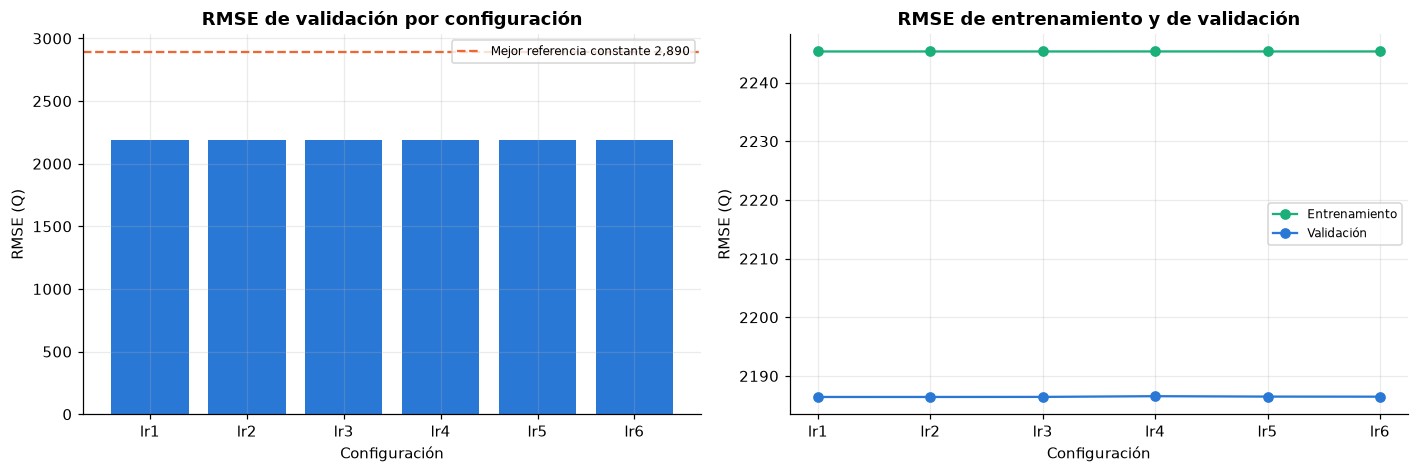

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(resultados_lr.index, resultados_lr["RMSE_validacion"], color=AZUL)
axes[0].axhline(referencias["RMSE"].min(), color=NARANJA, linestyle="--",
                label=f"Mejor referencia constante {referencias['RMSE'].min():,.0f}")
axes[0].set_title("RMSE de validación por configuración")
axes[0].set_ylabel("RMSE (Q)")
axes[0].legend(fontsize=8)

axes[1].plot(resultados_lr.index, resultados_lr["RMSE_entrenamiento"], marker="o", color=AQUA, label="Entrenamiento")
axes[1].plot(resultados_lr.index, resultados_lr["RMSE_validacion"], marker="o", color=AZUL, label="Validación")
axes[1].set_title("RMSE de entrenamiento y de validación")
axes[1].set_ylabel("RMSE (Q)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Configuración")
fig.tight_layout()
plt.show()

Las barras muestran el RMSE de validación de cada configuración junto con la mejor referencia constante. La distancia entre las configuraciones es pequeña frente a la distancia que separa a cualquiera de ellas de la referencia. Con seis predictores y un vector de features de pocas columnas, la penalización tiene poco margen para mejorar el ajuste, porque el modelo no llega a sobreajustar. El panel derecho compara el RMSE de entrenamiento con el de validación, y la diferencia entre ambos indica cuánto pierde el modelo al pasar a un trimestre que no vio.

La columna `coef_no_nulos` muestra cuántos coeficientes sobreviven en cada configuración. En las configuraciones con componente L1 puede bajar, porque esa penalización lleva coeficientes a cero de forma exacta.

### 5.5 Coeficientes del modelo elegido

In [36]:
lr_final = modelo_lr.stages[-1]
coeficientes = pd.DataFrame({
    "variable": NOMBRES_FEATURES,
    "coeficiente": lr_final.coefficients.toArray(),
}).sort_values("coeficiente", key=np.abs, ascending=False).reset_index(drop=True)
print(f"Intercepto {lr_final.intercept:,.2f} quetzales")
print("Coeficientes en quetzales por unidad de la variable. Las indicadoras no tienen categoría de referencia, se comparan entre categorías de la misma variable")
display(coeficientes)

metricas_lr = metricas(modelo_lr.transform(validacion))
comparacion_lr = pd.concat([
    referencias,
    pd.DataFrame([{"modelo": f"Regresión lineal {CONFIG_LR_ELEGIDA}", **metricas_lr}]).set_index("modelo"),
])
comparacion_lr["mejora_RMSE_pct"] = 100 * (1 - comparacion_lr["RMSE"] / referencias["RMSE"].min())
comparacion_lr["mejora_MAE_pct"] = 100 * (1 - comparacion_lr["MAE"] / referencias["MAE"].min())
print("Validación, trimestre IV de 2025")
comparacion_lr

Intercepto 1,775.50 quetzales
Coeficientes en quetzales por unidad de la variable. Las indicadoras no tienen categoría de referencia, se comparan entre categorías de la misma variable


,variable,coeficiente
0,nivel_educativo_ohe_DESCONOCIDO,"8,702.20"
1,nivel_educativo_ohe_Postgrado,"6,863.06"
2,nivel_educativo_ohe_Superior,"1,776.89"
3,categoria_ocupacional_ohe_Empleado de gobierno,"1,424.31"
4,categoria_ocupacional_ohe_Servicio doméstico,"-1,413.86"
5,nivel_educativo_ohe_Ninguno,"-1,250.90"
6,nivel_educativo_ohe_Preprimaria,-966.57
7,nivel_educativo_ohe_Primaria,-753.93
8,categoria_ocupacional_ohe_Jornalero o peón,-607.77
9,nivel_educativo_ohe_Básico,-548.72


Validación, trimestre IV de 2025


,MAE,RMSE,R2,mejora_RMSE_pct,mejora_MAE_pct
modelo,,,,,
"Referencia media Q3,383","1,672.50","2,889.57",-0.00,0.00,-0.13
"Referencia mediana Q3,000","1,670.39","2,936.00",-0.04,-1.61,0.00
Regresión lineal lr1,"1,210.14","2,186.42",0.43,24.33,27.55


### 5.6 Interpretación de la regresión lineal

La tabla anterior reporta MAE, RMSE y R² del modelo elegido sobre el trimestre de validación, junto con las dos referencias constantes y el porcentaje de mejora frente a la mejor de ellas en cada métrica.

El modelo queda por debajo de la referencia en las tres métricas, así que los seis predictores sí aportan información sobre el salario. El R² indica qué parte de la variación del salario en validación queda explicada. El resto proviene de factores que no están en estas seis variables, como la ocupación específica, el sector de actividad, el tamaño de la empresa, la región dentro del dominio y la experiencia previa a la ocupación actual.

La diferencia entre MAE y RMSE resume la forma de los errores. El RMSE es cercano al doble del MAE porque eleva al cuadrado, así que unos pocos registros con error grande pesan mucho en él. Esos registros son en su mayoría salarios de la cola derecha que se vio en la sección 2. El error típico se lee mejor en el MAE.

Sobre los coeficientes. La regresión lineal asume un efecto aditivo y constante de cada variable. Un coeficiente positivo en horas semanales indica que, entre registros que comparten las demás variables, más horas se asocian con un salario mayor. Las indicadoras no tienen una categoría de referencia, así que cada coeficiente se compara con los de las otras categorías de la misma variable y no con una base. En el nivel educativo, Postgrado y Superior tienen los coeficientes mayores y Ninguno, Preprimaria y Primaria los menores, lo que reproduce lo visto en las medianas por grupo de la sección 2. DESCONOCIDO tiene el coeficiente más alto porque agrupa solo 60 registros de salarios altos, y no debe interpretarse. Estas cifras son asociaciones dentro de esta muestra. No miden el efecto causal de estudiar un año más ni sirven para decir cuánto debería ganar una persona.

Una limitación que se arrastra a la sección 8. Como el modelo es lineal en el salario en quetzales y el salario tiene cola derecha, el ajuste concentra el esfuerzo en la parte central de la distribución. Es esperable que subestime los salarios altos y sobreestime los bajos.

## 6. Pipeline de Random Forest

El segundo pipeline usa las mismas etapas de preparación y los mismos conjuntos de entrenamiento y validación de la sección 5. Cambia el estimador final.

`RandomForestRegressor` construye varios árboles sobre muestras con reemplazo de los datos y con subconjuntos de variables en cada corte, y promedia sus predicciones. Los cortes dependen del orden de los valores y no de su escala, por eso este modelo no necesita estandarización y el pipeline no incluye `StandardScaler` ni la opción interna del estimador.

Una diferencia frente a la regresión lineal es que los árboles capturan relaciones no lineales y combinaciones entre variables sin que haya que escribirlas. Por ejemplo, el efecto de las horas puede ser distinto en servicio doméstico que en empleo de gobierno, y un árbol puede representar eso con cortes sucesivos.

### 6.1 Configuraciones de Random Forest

Se prueban cuatro configuraciones que varían el número de árboles y la profundidad máxima. Todas usan la semilla fija del notebook para que el resultado sea reproducible.

| Configuración | numTrees | maxDepth |
| --- | --- | --- |
| rf1 | 60 | 5 |
| rf2 | 60 | 10 |
| rf3 | 120 | 10 |
| rf4 | 120 | 15 |

El criterio de selección es el mismo de la sección anterior: el menor RMSE de validación.

In [37]:
CONFIGS_RF = {
    "rf1": {"numTrees": 60, "maxDepth": 5},
    "rf2": {"numTrees": 60, "maxDepth": 10},
    "rf3": {"numTrees": 120, "maxDepth": 10},
    "rf4": {"numTrees": 120, "maxDepth": 15},
}

resultados_rf, modelos_rf = [], {}
for nombre, cfg in CONFIGS_RF.items():
    pipeline = Pipeline(stages=etapas_categoricas() + [
        RandomForestRegressor(featuresCol="features", labelCol=OBJETIVO, seed=SEMILLA, maxBins=64, **cfg)
    ])
    modelo = pipeline.fit(entrenamiento)
    m_ent = metricas(modelo.transform(entrenamiento))
    m_val = metricas(modelo.transform(validacion))
    resultados_rf.append({
        "config": nombre, **cfg,
        "nodos_totales": modelo.stages[-1].totalNumNodes,
        "RMSE_entrenamiento": m_ent["RMSE"],
        "MAE_validacion": m_val["MAE"], "RMSE_validacion": m_val["RMSE"], "R2_validacion": m_val["R2"],
    })
    modelos_rf[nombre] = modelo

resultados_rf = pd.DataFrame(resultados_rf).set_index("config")
CONFIG_RF_ELEGIDA = resultados_rf["RMSE_validacion"].idxmin()
modelo_rf = modelos_rf[CONFIG_RF_ELEGIDA]
display(resultados_rf)
print(f"Configuración elegida {CONFIG_RF_ELEGIDA} con numTrees {CONFIGS_RF[CONFIG_RF_ELEGIDA]['numTrees']} "
      f"y maxDepth {CONFIGS_RF[CONFIG_RF_ELEGIDA]['maxDepth']}")

,numTrees,maxDepth,nodos_totales,RMSE_entrenamiento,MAE_validacion,RMSE_validacion,R2_validacion
config,,,,,,,
rf1,60,5,3528,"2,191.32","1,158.64","2,155.77",0.44
rf2,60,10,50292,"1,911.95","1,074.19","1,963.62",0.54
rf3,120,10,101634,"1,897.58","1,073.85","1,960.85",0.54
rf4,120,15,455218,"1,732.81","1,039.22","1,896.18",0.57


Configuración elegida rf4 con numTrees 120 y maxDepth 15


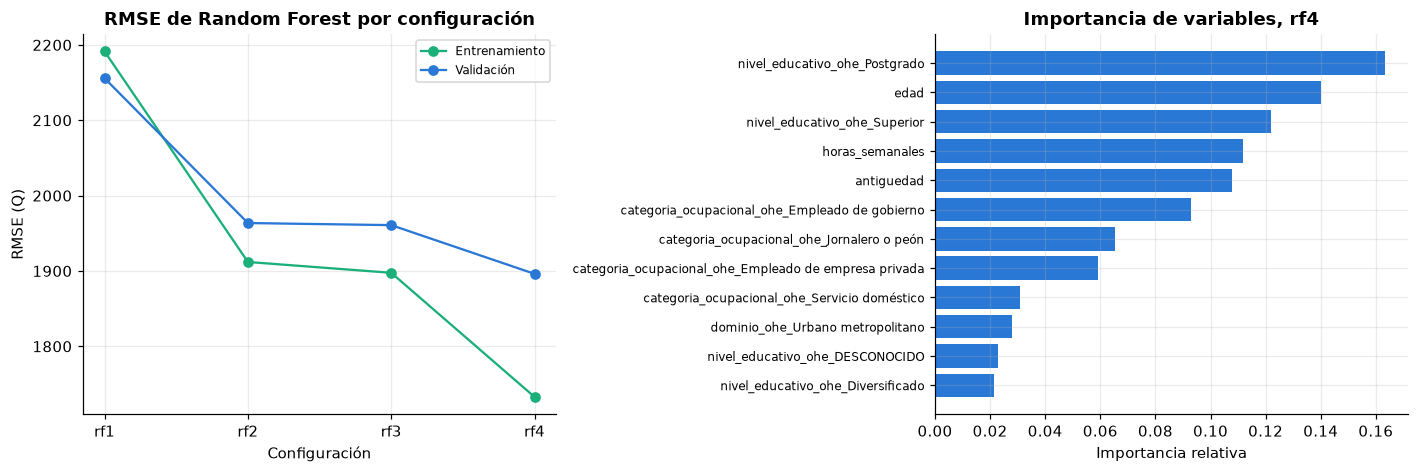

Importancia de variables del modelo elegido


,importancia
nivel_educativo_ohe_Postgrado,0.16
edad,0.14
nivel_educativo_ohe_Superior,0.12
horas_semanales,0.11
antiguedad,0.11
categoria_ocupacional_ohe_Empleado de gobierno,0.09
categoria_ocupacional_ohe_Jornalero o peón,0.07
categoria_ocupacional_ohe_Empleado de empresa privada,0.06
categoria_ocupacional_ohe_Servicio doméstico,0.03
dominio_ohe_Urbano metropolitano,0.03


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(resultados_rf.index, resultados_rf["RMSE_entrenamiento"], marker="o", color=AQUA, label="Entrenamiento")
axes[0].plot(resultados_rf.index, resultados_rf["RMSE_validacion"], marker="o", color=AZUL, label="Validación")
axes[0].set_title("RMSE de Random Forest por configuración")
axes[0].set_xlabel("Configuración")
axes[0].set_ylabel("RMSE (Q)")
axes[0].legend(fontsize=8)

importancias = pd.Series(modelo_rf.stages[-1].featureImportances.toArray(), index=NOMBRES_FEATURES)
importancias = importancias.sort_values(ascending=True).tail(12)
axes[1].barh(importancias.index, importancias.values, color=AZUL)
axes[1].set_title(f"Importancia de variables, {CONFIG_RF_ELEGIDA}")
axes[1].set_xlabel("Importancia relativa")
axes[1].tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()

print("Importancia de variables del modelo elegido")
pd.Series(modelo_rf.stages[-1].featureImportances.toArray(), index=NOMBRES_FEATURES) \
    .sort_values(ascending=False).to_frame("importancia")

La curva de la izquierda separa el RMSE de entrenamiento del de validación. Al subir la profundidad máxima el RMSE de entrenamiento baja porque los árboles distinguen más combinaciones de valores. Si el RMSE de validación deja de bajar o sube mientras el de entrenamiento sigue bajando, esa configuración está memorizando el conjunto de entrenamiento y la diferencia entre ambas curvas mide ese exceso de ajuste. La columna `nodos_totales` de la tabla da una medida del tamaño del bosque y acompaña esa lectura.

En esta ejecución el RMSE de entrenamiento baja de Q2,191 en `rf1` a Q1,733 en `rf4`, y el de validación de Q2,156 a Q1,896. La validación sigue bajando junto con el entrenamiento, aunque en `rf4` aparece una brecha, Q1,733 de entrenamiento frente a Q1,896 de validación. Hay algo de exceso de ajuste, pero no el suficiente para que la configuración más profunda deje de ser la mejor.

Las importancias de la derecha indican qué fracción de la reducción de varianza aporta cada columna del vector `features` a lo largo de los árboles. Se leen con cuidado en dos sentidos. Suman uno, así que son relativas y no dicen cuánto salario explica cada variable. Además, las variables numéricas continuas tienen más puntos de corte posibles que una indicadora binaria, lo que tiende a favorecerlas en esta métrica.

### 6.2 Comparación entre los dos algoritmos

Validación, trimestre IV de 2025, métricas sobre todos los registros elegibles


,MAE,RMSE,R2,mejora_RMSE_pct,mejora_MAE_pct
modelo,,,,,
"Referencia media Q3,383","1,672.50","2,889.57",-0.00,0.00,-0.13
"Referencia mediana Q3,000","1,670.39","2,936.00",-0.04,-1.61,0.00
Regresión lineal lr1,"1,210.14","2,186.42",0.43,24.33,27.55
Random Forest rf4,"1,039.22","1,896.18",0.57,34.38,37.79


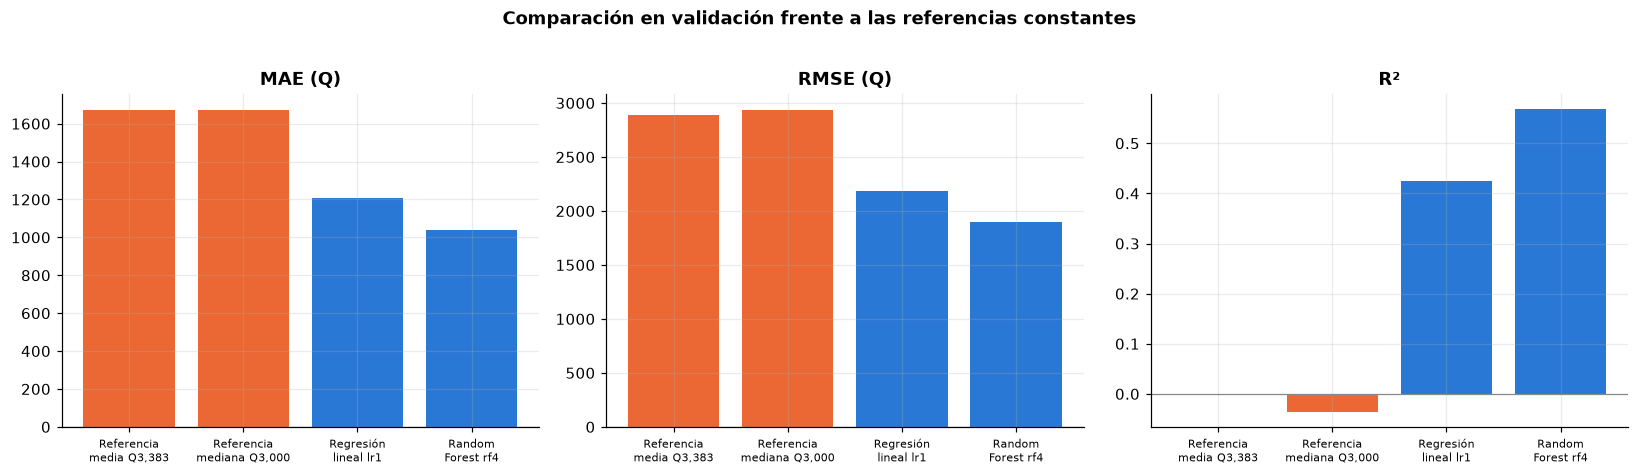

Menor RMSE de validación entre los dos algoritmos: Random Forest rf4


In [39]:
comparacion = pd.concat([
    referencias,
    pd.DataFrame([
        {"modelo": f"Regresión lineal {CONFIG_LR_ELEGIDA}", **metricas(modelo_lr.transform(validacion))},
        {"modelo": f"Random Forest {CONFIG_RF_ELEGIDA}", **metricas(modelo_rf.transform(validacion))},
    ]).set_index("modelo"),
])
base_rmse, base_mae = referencias["RMSE"].min(), referencias["MAE"].min()
comparacion["mejora_RMSE_pct"] = 100 * (1 - comparacion["RMSE"] / base_rmse)
comparacion["mejora_MAE_pct"] = 100 * (1 - comparacion["MAE"] / base_mae)
print("Validación, trimestre IV de 2025, métricas sobre todos los registros elegibles")
display(comparacion)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
etiquetas = [m.replace(" ", "\n", 1) for m in comparacion.index]
for ax, metrica, titulo in [(axes[0], "MAE", "MAE (Q)"), (axes[1], "RMSE", "RMSE (Q)"), (axes[2], "R2", "R²")]:
    colores = [NARANJA if "Referencia" in m else AZUL for m in comparacion.index]
    ax.bar(etiquetas, comparacion[metrica], color=colores)
    ax.set_title(titulo)
    ax.tick_params(axis="x", labelsize=7)
    ax.axhline(0, color="#888888", linewidth=0.8)
fig.suptitle("Comparación en validación frente a las referencias constantes", y=1.02, fontweight="bold")
fig.tight_layout()
plt.show()

MEJOR_ALGORITMO = comparacion.loc[[i for i in comparacion.index if "Referencia" not in i], "RMSE"].idxmin()
print(f"Menor RMSE de validación entre los dos algoritmos: {MEJOR_ALGORITMO}")

### 6.3 Qué algoritmo funciona mejor en validación y por qué

La tabla y las barras anteriores responden la comparación con las mismas métricas y sobre los mismos registros. El modelo con menor RMSE de validación queda impreso al final de la celda. En esta ejecución gana el Random Forest `rf4`, con un RMSE de Q1,896 frente a Q2,186 de la regresión lineal `lr1`, un MAE de Q1,039 frente a Q1,210 y un R² de 0.57 frente a 0.43. La ventaja aparece en las tres métricas.

Las diferencias entre los dos algoritmos tienen explicaciones que conviene separar.

La regresión lineal impone una forma: el salario es una suma de términos, cada variable numérica entra con una pendiente fija y cada categoría con un desplazamiento fijo. Si la relación real se acerca a esa forma, el modelo la recupera con pocos parámetros y con varianza baja. Si la relación tiene curvatura o depende de combinaciones entre variables, la regresión no puede representarla y queda con sesgo.

Random Forest no impone esa forma. Divide el espacio de los predictores en regiones y predice el promedio del salario dentro de cada región, así que representa curvatura y combinaciones entre variables. El costo es que su predicción es un promedio de valores observados en entrenamiento, y por construcción queda acotada por el rango de esos promedios. Con un objetivo de cola derecha larga, eso limita cuánto puede acercarse a los salarios más altos.

Hay un factor que afecta a ambos por igual. Los seis predictores no incluyen la ocupación específica ni el sector de actividad, que son determinantes fuertes del salario. Por eso el R² de los dos queda lejos de 1, 0.43 con la regresión lineal y 0.57 con el Random Forest en validación.

Sobre la elección de la configuración dentro de cada algoritmo. En la regresión lineal la regularización cambia poco el resultado porque el vector de features tiene pocas columnas frente al número de registros. En Random Forest la profundidad máxima es la que manda, porque controla de forma directa cuánto puede ajustarse el bosque al conjunto de entrenamiento.

### 6.4 Guardado de los modelos elegidos

Se guarda un modelo por algoritmo, en ambos casos el de menor RMSE de validación. Los modelos guardados son pipelines completos, así que incluyen los indexadores, el codificador y el ensamblador ajustados con los datos de entrenamiento. Esto evita repetir la preparación por separado y garantiza que en 2026 se apliquen exactamente las mismas transformaciones.

En esta etapa los modelos siguen ajustados solo con los trimestres I, II y III de 2025. El trimestre IV sirvió para elegir la configuración y todavía no entró al ajuste. El primer trimestre de 2026 no se ha tocado y queda reservado para la sección 7.

In [40]:
DIR_MODELOS = Path("models")
DIR_MODELOS.mkdir(parents=True, exist_ok=True)

RUTA_MODELO_LR = DIR_MODELOS / "regresion_lineal"
RUTA_MODELO_RF = DIR_MODELOS / "random_forest"
modelo_lr.write().overwrite().save(str(RUTA_MODELO_LR))
modelo_rf.write().overwrite().save(str(RUTA_MODELO_RF))

CONFIG_ELEGIDA = {
    "regresion_lineal": {"config": CONFIG_LR_ELEGIDA, **CONFIGS_LR[CONFIG_LR_ELEGIDA], "ruta": str(RUTA_MODELO_LR)},
    "random_forest": {"config": CONFIG_RF_ELEGIDA, **CONFIGS_RF[CONFIG_RF_ELEGIDA], "ruta": str(RUTA_MODELO_RF)},
}
for algoritmo, cfg in CONFIG_ELEGIDA.items():
    print(f"{algoritmo}: {cfg}")

periodos_usados = [f.periodo_archivo for f in entrenamiento.select("periodo_archivo").distinct().collect()]
print(f"Períodos usados en el ajuste {sorted(periodos_usados)}")
print(f"Trimestre reservado para la evaluación final: 2026T1 con {df26.count():,} registros preparados, sin usar")

regresion_lineal: {'config': 'lr1', 'regParam': 0.0, 'elasticNetParam': 0.0, 'ruta': 'models/regresion_lineal'}
random_forest: {'config': 'rf4', 'numTrees': 120, 'maxDepth': 15, 'ruta': 'models/random_forest'}
Períodos usados en el ajuste ['2025T1', '2025T2', '2025T3']
Trimestre reservado para la evaluación final: 2026T1 con 13,258 registros preparados, sin usar


## 7. Entrenamiento final y evaluación en 2026

Con las configuraciones elegidas en las secciones 5 y 6 se cierra el ciclo. Esta es la primera vez que el notebook usa el primer trimestre de 2026.

### 7.1 Ajuste final con los cuatro trimestres de 2025

La selección de configuraciones ya terminó. El trimestre IV de 2025 cumplió su papel de validación y ahora se suma al entrenamiento, como indica el enunciado. Para cada algoritmo se ajusta de nuevo, desde cero, el pipeline completo con la configuración elegida. No se vuelve a comparar configuraciones ni se mira 2026 para decidir nada.

Todas las etapas se ajustan solo con los registros de 2025. Las categorías observadas, los índices, la estandarización y el modelo salen de esos registros. Las referencias constantes se recalculan con la media y la mediana de esos mismos registros.

Los modelos de las secciones 5 y 6 se ajustaron con tres trimestres y los de esta sección con cuatro. Por eso las métricas de validación y las de prueba no corresponden exactamente al mismo modelo. Se muestran juntas más adelante solo como orientación.

Antes de ajustar se revisa el conjunto de 2026. La base ya pasó en la sección 1 por las mismas reglas de preparación que la de 2025, así que no se filtra otra vez. Aquí solo se comprueba que no queden nulos en el objetivo ni en los predictores, y cuántos registros traen una categoría que no aparece en 2025. Esos registros no se excluyen. El `handleInvalid="keep"` de los indexadores les asigna un índice propio y el modelo los procesa sin detenerse.

In [41]:
PERIODOS_FINAL = ["2025T1", "2025T2", "2025T3", "2025T4"]
entrenamiento_final = df25.filter(F.col("periodo_archivo").isin(PERIODOS_FINAL)).select(*columnas_modelo).cache()
n_final = entrenamiento_final.count()
print(f"Entrenamiento final {n_final:,} registros de {', '.join(PERIODOS_FINAL)}")
print(f"Coincide con la base preparada de 2025 {n_final == df25.count()}")

# El identificador se asigna una sola vez sobre un DataFrame en caché. Así las predicciones de los
# dos modelos y de las referencias se unen por registro y se evalúan sobre exactamente las mismas filas
prueba = df26.select(*columnas_modelo).withColumn("id_prueba", F.monotonically_increasing_id()).cache()
n_prueba = prueba.count()
periodos_prueba = [f.periodo_archivo for f in prueba.select("periodo_archivo").distinct().collect()]
print(f"Prueba {n_prueba:,} registros de {', '.join(periodos_prueba)}")

nulos = prueba.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in [OBJETIVO] + PREDICTORES]).first().asDict()
print(f"Nulos en objetivo y predictores de prueba {nulos}")
assert sum(nulos.values()) == 0, "La base de prueba tiene nulos en objetivo o predictores"
assert prueba.filter(~(F.col(OBJETIVO) > 0)).count() == 0, "La base de prueba tiene salarios no positivos"

categorias_nuevas = []
for c in CATEGORICAS:
    vistas = [f[0] for f in entrenamiento_final.select(c).distinct().collect()]
    n_nuevas = prueba.filter(~F.col(c).isin(vistas)).count()
    categorias_nuevas.append({"variable": c, "categorias_en_2025": len(vistas), "registros_2026_con_categoria_nueva": n_nuevas})
pd.DataFrame(categorias_nuevas).set_index("variable")

Entrenamiento final 53,025 registros de 2025T1, 2025T2, 2025T3, 2025T4
Coincide con la base preparada de 2025 True
Prueba 13,258 registros de 2026T1


Nulos en objetivo y predictores de prueba {'salario_mensual': 0, 'edad': 0, 'antiguedad': 0, 'horas_semanales': 0, 'nivel_educativo': 0, 'categoria_ocupacional': 0, 'dominio': 0}


,categorias_en_2025,registros_2026_con_categoria_nueva
variable,,
nivel_educativo,8,0
categoria_ocupacional,4,0
dominio,3,0


### 7.2 Reajuste de los dos pipelines

Las funciones construyen los mismos pipelines de las secciones 5 y 6, con las etapas de `etapas_categoricas()` y el estimador correspondiente. Los valores de `regParam`, `elasticNetParam`, `numTrees` y `maxDepth` son los de las configuraciones elegidas por menor RMSE de validación. El Random Forest conserva la semilla fija.

Los modelos finales se guardan en `models` junto a los de la sección 6, con el prefijo `final_`.

In [42]:
def pipeline_lr(cfg):
    return Pipeline(stages=etapas_categoricas() + [
        LinearRegression(featuresCol="features", labelCol=OBJETIVO, standardization=True, maxIter=100, tol=1e-6, **cfg)
    ])


def pipeline_rf(cfg):
    return Pipeline(stages=etapas_categoricas() + [
        RandomForestRegressor(featuresCol="features", labelCol=OBJETIVO, seed=SEMILLA, maxBins=64, **cfg)
    ])


cfg_lr_final = CONFIGS_LR[CONFIG_LR_ELEGIDA]
cfg_rf_final = CONFIGS_RF[CONFIG_RF_ELEGIDA]
modelo_lr_final = pipeline_lr(cfg_lr_final).fit(entrenamiento_final)
modelo_rf_final = pipeline_rf(cfg_rf_final).fit(entrenamiento_final)

media_final = entrenamiento_final.agg(F.mean(OBJETIVO)).first()[0]
mediana_final = entrenamiento_final.agg(F.expr(f"percentile({OBJETIVO}, 0.5)")).first()[0]

RUTA_FINAL_LR = DIR_MODELOS / "final_regresion_lineal"
RUTA_FINAL_RF = DIR_MODELOS / "final_random_forest"
modelo_lr_final.write().overwrite().save(str(RUTA_FINAL_LR))
modelo_rf_final.write().overwrite().save(str(RUTA_FINAL_RF))

print(f"Regresión lineal {CONFIG_LR_ELEGIDA} {cfg_lr_final} guardada en {RUTA_FINAL_LR}")
print(f"Random Forest {CONFIG_RF_ELEGIDA} {cfg_rf_final} guardado en {RUTA_FINAL_RF}")
print(f"Referencias recalculadas con {n_final:,} registros. Media Q{media_final:,.2f} y mediana Q{mediana_final:,.2f}")

Regresión lineal lr1 {'regParam': 0.0, 'elasticNetParam': 0.0} guardada en models/final_regresion_lineal
Random Forest rf4 {'numTrees': 120, 'maxDepth': 15} guardado en models/final_random_forest
Referencias recalculadas con 53,025 registros. Media Q3,421.68 y mediana Q3,000.00


### 7.3 Predicciones sobre el primer trimestre de 2026

Cada pipeline ajustado transforma el mismo DataFrame de prueba. Las predicciones de los dos modelos y las dos constantes de referencia quedan como columnas de un solo DataFrame, `pred26`, unidas por `id_prueba`. Las métricas de todos los modelos se calculan sobre este DataFrame completo, de modo que comparten exactamente los mismos registros. La muestra de hasta 5,000 registros que se usa para graficar en la sección 8 saldrá de este mismo DataFrame.

Las métricas son MAE, RMSE y R², las mismas de las secciones 5 y 6. El residuo se define como salario real menos salario predicho. Un residuo positivo indica subestimación y uno negativo, sobreestimación.

In [43]:
pred_lr = (modelo_lr_final.transform(prueba)
           .select("id_prueba", OBJETIVO, *PREDICTORES, "periodo_archivo", F.col("prediction").alias("pred_lr")))
pred_rf = modelo_rf_final.transform(prueba).select("id_prueba", F.col("prediction").alias("pred_rf"))

pred26 = (pred_lr.join(pred_rf, "id_prueba", "inner")
          .withColumn("pred_media", F.lit(float(media_final)))
          .withColumn("pred_mediana", F.lit(float(mediana_final)))
          .cache())

n_pred = pred26.count()
sin_prediccion = pred26.filter(F.col("pred_lr").isNull() | F.col("pred_rf").isNull()).count()
print(f"Registros de prueba {n_prueba:,}. Registros con predicción de ambos modelos {n_pred:,}. Sin predicción {sin_prediccion:,}")
assert n_pred == n_prueba and sin_prediccion == 0, "Los dos modelos no cubren exactamente los mismos registros"

pred26.select(OBJETIVO, "pred_lr", "pred_rf", "edad", "nivel_educativo", "categoria_ocupacional", "dominio").limit(5).toPandas()

Registros de prueba 13,258. Registros con predicción de ambos modelos 13,258. Sin predicción 0


,salario_mensual,pred_lr,pred_rf,edad,nivel_educativo,categoria_ocupacional,dominio
0,"3,000.00","1,948.53","2,362.22",37.00,Básico,Jornalero o peón,Resto urbano
1,"2,400.00","1,777.69","1,888.36",17.00,Primaria,Jornalero o peón,Urbano metropolitano
2,"2,400.00","1,405.17","2,093.43",34.00,Ninguno,Jornalero o peón,Rural nacional
3,"4,000.00","4,156.65","4,136.33",31.00,Diversificado,Empleado de empresa privada,Urbano metropolitano
4,"2,800.00","1,969.09","2,009.33",50.00,Primaria,Jornalero o peón,Rural nacional


### 7.4 Métricas en la prueba de 2026 y comparación con validación

Prueba, primer trimestre de 2026, métricas sobre 13,258 registros


,MAE,RMSE,R2,mejora_RMSE_pct,mejora_MAE_pct
modelo,,,,,
"Referencia media Q3,422","1,718.09","2,871.42",-0.00,0.00,0.00
"Referencia mediana Q3,000","1,718.68","2,923.08",-0.04,-1.80,-0.03
Regresión lineal lr1,"1,240.71","2,163.75",0.43,24.65,27.79
Random Forest rf4,"1,071.19","1,882.80",0.57,34.43,37.65


Las mismas métricas en validación y en prueba


Validación 2025T4 (modelo con 3 trimestres)               Prueba 2026T1 (modelo con 4 trimestres)              
                                                             MAE     RMSE   R2                                     MAE     RMSE   R2
modelo                                                                                                                              
Regresión lineal lr1                                    1,210.14 2,186.42 0.43                                1,240.71 2,163.75 0.43
Random Forest rf4                                       1,039.22 1,896.18 0.57                                1,071.19 1,882.80 0.57

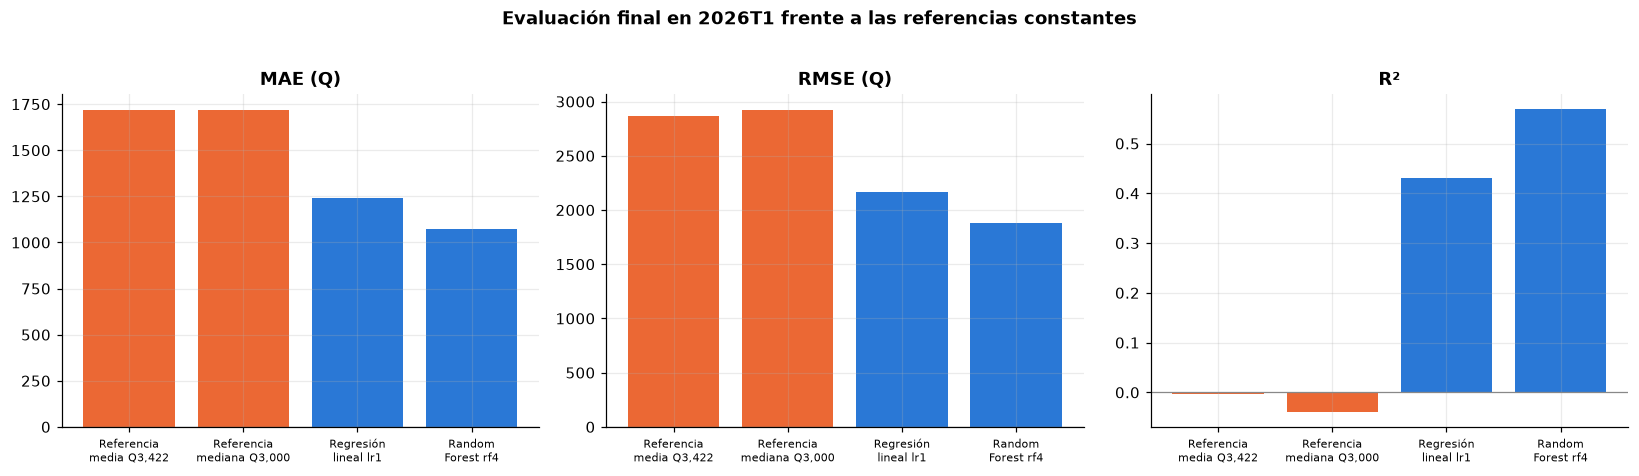

Menor RMSE en la prueba entre los dos algoritmos: Random Forest rf4
Menor RMSE en validación entre los dos algoritmos: Random Forest rf4
El orden de los algoritmos se mantiene entre validación y prueba


In [44]:
def metricas_pred(df, columna):
    return metricas(df.select(OBJETIVO, F.col(columna).alias("prediction")))


NOMBRE_LR = f"Regresión lineal {CONFIG_LR_ELEGIDA}"
NOMBRE_RF = f"Random Forest {CONFIG_RF_ELEGIDA}"
COLUMNAS_PRUEBA = {
    f"Referencia media Q{media_final:,.0f}": "pred_media",
    f"Referencia mediana Q{mediana_final:,.0f}": "pred_mediana",
    NOMBRE_LR: "pred_lr",
    NOMBRE_RF: "pred_rf",
}
metricas_prueba = pd.DataFrame([
    {"modelo": nombre, **metricas_pred(pred26, columna)} for nombre, columna in COLUMNAS_PRUEBA.items()
]).set_index("modelo")

es_referencia = ["Referencia" in m for m in metricas_prueba.index]
base_rmse_prueba = metricas_prueba.loc[es_referencia, "RMSE"].min()
base_mae_prueba = metricas_prueba.loc[es_referencia, "MAE"].min()
metricas_prueba["mejora_RMSE_pct"] = 100 * (1 - metricas_prueba["RMSE"] / base_rmse_prueba)
metricas_prueba["mejora_MAE_pct"] = 100 * (1 - metricas_prueba["MAE"] / base_mae_prueba)
print(f"Prueba, primer trimestre de 2026, métricas sobre {n_pred:,} registros")
display(metricas_prueba)

modelos_finales = [NOMBRE_LR, NOMBRE_RF]
validacion_vs_prueba = pd.concat({
    "Validación 2025T4 (modelo con 3 trimestres)": comparacion.loc[modelos_finales, ["MAE", "RMSE", "R2"]],
    "Prueba 2026T1 (modelo con 4 trimestres)": metricas_prueba.loc[modelos_finales, ["MAE", "RMSE", "R2"]],
}, axis=1)
print("Las mismas métricas en validación y en prueba")
display(validacion_vs_prueba)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
etiquetas = [m.replace(" ", "\n", 1) for m in metricas_prueba.index]
for ax, metrica, titulo in [(axes[0], "MAE", "MAE (Q)"), (axes[1], "RMSE", "RMSE (Q)"), (axes[2], "R2", "R²")]:
    colores = [NARANJA if "Referencia" in m else AZUL for m in metricas_prueba.index]
    ax.bar(etiquetas, metricas_prueba[metrica], color=colores)
    ax.set_title(titulo)
    ax.tick_params(axis="x", labelsize=7)
    ax.axhline(0, color="#888888", linewidth=0.8)
fig.suptitle("Evaluación final en 2026T1 frente a las referencias constantes", y=1.02, fontweight="bold")
fig.tight_layout()
plt.show()

MEJOR_EN_PRUEBA = metricas_prueba.loc[modelos_finales, "RMSE"].idxmin()
print(f"Menor RMSE en la prueba entre los dos algoritmos: {MEJOR_EN_PRUEBA}")
print(f"Menor RMSE en validación entre los dos algoritmos: {MEJOR_ALGORITMO}")
print(f"El orden de los algoritmos {'se mantiene' if MEJOR_EN_PRUEBA == MEJOR_ALGORITMO else 'cambia'} entre validación y prueba")

### 7.5 Interpretación de la evaluación final

Las dos primeras tablas de arriba responden la comparación que pide el enunciado. Los dos modelos y las dos constantes se evalúan sobre los mismos registros de 2026T1, con MAE, RMSE y R². La última línea de la celda indica qué algoritmo tiene el menor RMSE en la prueba y si coincide con el que ganó en validación.

**Frente a la referencia.** La columna `mejora_RMSE_pct` y la columna `mejora_MAE_pct` miden cuánto baja cada error respecto de la mejor constante. Un modelo que no mejora a la constante no aporta nada con estos seis predictores. Si el R² es positivo, el modelo explica parte de la variación del salario en un trimestre que no vio. La parte que queda sin explicar corresponde a factores que no están en las seis variables, como la ocupación específica, el sector o el tamaño de la empresa.

**Entre algoritmos.** La diferencia entre la regresión lineal y el Random Forest se lee con las tres métricas a la vez. El RMSE eleva el error al cuadrado y por eso pesa más en los salarios altos de la cola derecha. El MAE describe mejor el error típico. Si un modelo gana en una métrica y pierde en otra, la diferencia viene de cómo trata a esos salarios extremos, y conviene decirlo en lugar de nombrar un solo ganador. Las razones por las que un algoritmo puede superar al otro ya se discutieron en la sección 6.3 y aquí se contrastan con lo que ocurrió en 2026.

**Validación contra prueba.** Una prueba con métricas parecidas a las de validación indica que el modelo generaliza a un trimestre nuevo. Si el error sube, hay tres explicaciones posibles. El nivel o la composición del salario puede haber cambiado entre 2025 y 2026. Los datos de prueba pueden traer categorías poco frecuentes o distintas, como las que cuenta la tabla de 7.1. O la configuración elegida en validación se ajustó al ruido de un solo trimestre. El modelo de prueba tiene además un trimestre más de entrenamiento que el de validación, así que la comparación es indicativa y no exacta.

**Resultados de la ejecución de referencia.** En 2026T1 hay 13,258 registros elegibles y la mejor referencia constante tiene un RMSE de Q2,871 y un MAE de Q1,718. La regresión lineal `lr1` obtiene un MAE de Q1,241, un RMSE de Q2,164 y un R² de 0.43, es decir, mejoras de 27.8 % en el MAE y 24.7 % en el RMSE. El Random Forest `rf4` obtiene un MAE de Q1,071, un RMSE de Q1,883 y un R² de 0.57, con mejoras de 37.7 % y 34.4 %. El Random Forest gana en las tres métricas, igual que en validación. Las métricas casi no cambian entre validación y prueba. El RMSE de la regresión lineal pasa de Q2,186 a Q2,164 y el del Random Forest de Q1,896 a Q1,883, así que los modelos generalizan a un trimestre nuevo sin pérdida visible. Ninguno de los 13,258 registros de 2026 trae una categoría ausente de 2025. Las cifras pueden variar un poco si se ejecuta en otra máquina.

**Alcance.** La prueba es un solo trimestre. Una diferencia pequeña entre dos modelos en 2026T1 no basta para afirmar que uno sea mejor en general. Las métricas no están ponderadas, describen a los registros analizados y no son estimaciones para la población de Guatemala.

Los residuos por nivel educativo, por dominio y por nivel de salario, y si hay tendencia a subestimar los salarios altos, se analizan en la sección 8 con las predicciones de `pred26`.

## 8. Visualización y análisis de errores

Esta sección analiza los errores de los dos modelos finales sobre el primer trimestre de 2026. Usa el DataFrame `pred26` de la sección 7, que tiene las predicciones de ambos modelos sobre exactamente los mismos registros.

**Definición del residuo.** En todo el notebook el residuo es salario real menos salario predicho. Un residuo positivo indica subestimación, porque el modelo predijo menos de lo que la persona ganaba. Un residuo negativo indica sobreestimación. El error medio de un grupo es el promedio de sus residuos con signo. Un error medio positivo significa que en ese grupo el modelo tiende a subestimar. El MAE es el promedio de los residuos en valor absoluto y no distingue el signo.

**Muestra para graficar.** Las gráficas de dispersión usan una sola muestra de hasta 5,000 registros que se comparte entre los dos modelos. Así ambos paneles muestran las mismas personas y se pueden comparar a simple vista. Las tablas y las métricas por grupo se calculan con todos los registros de prueba.

In [45]:
err26 = (pred26
         .withColumn("res_lr", F.col(OBJETIVO) - F.col("pred_lr"))
         .withColumn("res_rf", F.col(OBJETIVO) - F.col("pred_rf"))
         .cache())
n_err = err26.count()

# Una sola muestra de hasta 5,000 registros para los dos modelos, solo para dibujar
fraccion = min(1.0, 6000 / n_err)
muestra = (err26.select("id_prueba", OBJETIVO, "pred_lr", "pred_rf", "res_lr", "res_rf")
           .sample(fraction=fraccion, seed=SEMILLA).limit(5000).toPandas())
print(f"Registros de prueba {n_err:,}. Muestra para graficar {len(muestra):,} registros, la misma para ambos modelos")

MODELOS_GRAFICA = [("Regresión lineal", "pred_lr", "res_lr", AZUL), ("Random Forest", "pred_rf", "res_rf", NARANJA)]
tope_salario = muestra[OBJETIVO].quantile(0.99)
piso_pred = min(0.0, muestra[["pred_lr", "pred_rf"]].quantile(0.005).min())
print(f"Los ejes se recortan en Q{tope_salario:,.0f}, el percentil 99 del salario real de la muestra. "
      f"Quedan fuera del recorte {(muestra[OBJETIVO] > tope_salario).sum()} de {len(muestra):,} puntos")
print(f"Predicciones negativas en la muestra: regresión lineal {(muestra['pred_lr'] < 0).sum()}, "
      f"Random Forest {(muestra['pred_rf'] < 0).sum()}")

Registros de prueba 13,258. Muestra para graficar 5,000 registros, la misma para ambos modelos
Los ejes se recortan en Q15,000, el percentil 99 del salario real de la muestra. Quedan fuera del recorte 45 de 5,000 puntos
Predicciones negativas en la muestra: regresión lineal 13, Random Forest 0


### 8.1 Salario real frente a salario predicho

Cada punto es un registro de prueba. El eje horizontal es el salario real y el vertical el predicho. La línea punteada es y = x, donde estaría un modelo sin error. Los puntos por debajo de la línea son registros que el modelo subestimó y los que están por encima, registros que sobreestimó. Los ejes están en quetzales con escala lineal y se recortan en el percentil 99 del salario real para que la masa de los datos no quede comprimida contra el origen.

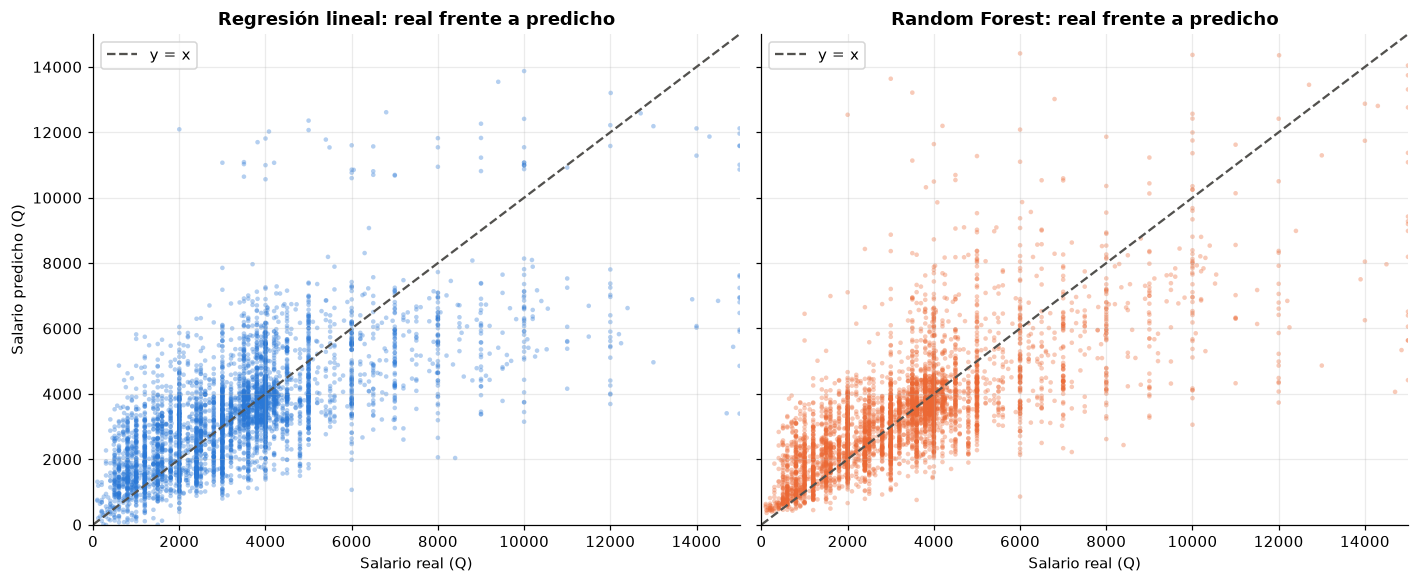

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharex=True, sharey=True)
for ax, (nombre, pred, res, color) in zip(axes, MODELOS_GRAFICA):
    ax.scatter(muestra[OBJETIVO], muestra[pred], s=9, alpha=0.35, color=color, edgecolors="none")
    ax.plot([0, tope_salario], [0, tope_salario], color="#52514e", ls="--", lw=1.5, label="y = x")
    ax.set_xlim(0, tope_salario)
    ax.set_ylim(piso_pred, tope_salario)
    ax.set_title(f"{nombre}: real frente a predicho")
    ax.set_xlabel("Salario real (Q)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Salario predicho (Q)")
fig.tight_layout()
plt.show()

En ambos paneles la nube forma una banda ancha alrededor de la línea y = x y la dispersión aumenta con el salario. Las columnas verticales de puntos aparecen porque los salarios reportados son montos redondos, como Q1,000, Q2,000 o Q3,000. Para un mismo monto real, los modelos dan predicciones muy distintas según el perfil. Con estos seis predictores no se logra separar a personas con perfiles parecidos y salarios distintos.

La regresión lineal produce predicciones que llegan a valores muy bajos y a veces negativos, 13 de los 5,000 puntos de la muestra. El Random Forest queda dentro del rango de salarios observados y no produce negativos en la muestra. En los salarios reales altos, a la derecha del gráfico, la mayoría de los puntos queda por debajo de la línea, es decir, los modelos subestiman. Eso se cuantifica en 8.3.

### 8.2 Residuos frente al salario predicho

El eje horizontal es el salario predicho y el vertical el residuo, salario real menos predicho. La línea horizontal en cero marca el error nulo. Si los residuos se repartieran sin patrón alrededor de cero, los puntos formarían una banda pareja sobre esa línea. La línea gruesa de cada panel es el residuo promedio por décimos del salario predicho dentro de la muestra, y sirve para ver si hay tendencia. El eje vertical se recorta entre los percentiles 1 y 99 de los residuos de la muestra.

Regresión lineal: 98 de 5,000 puntos de la muestra quedan fuera del recorte vertical
Random Forest: 91 de 5,000 puntos de la muestra quedan fuera del recorte vertical


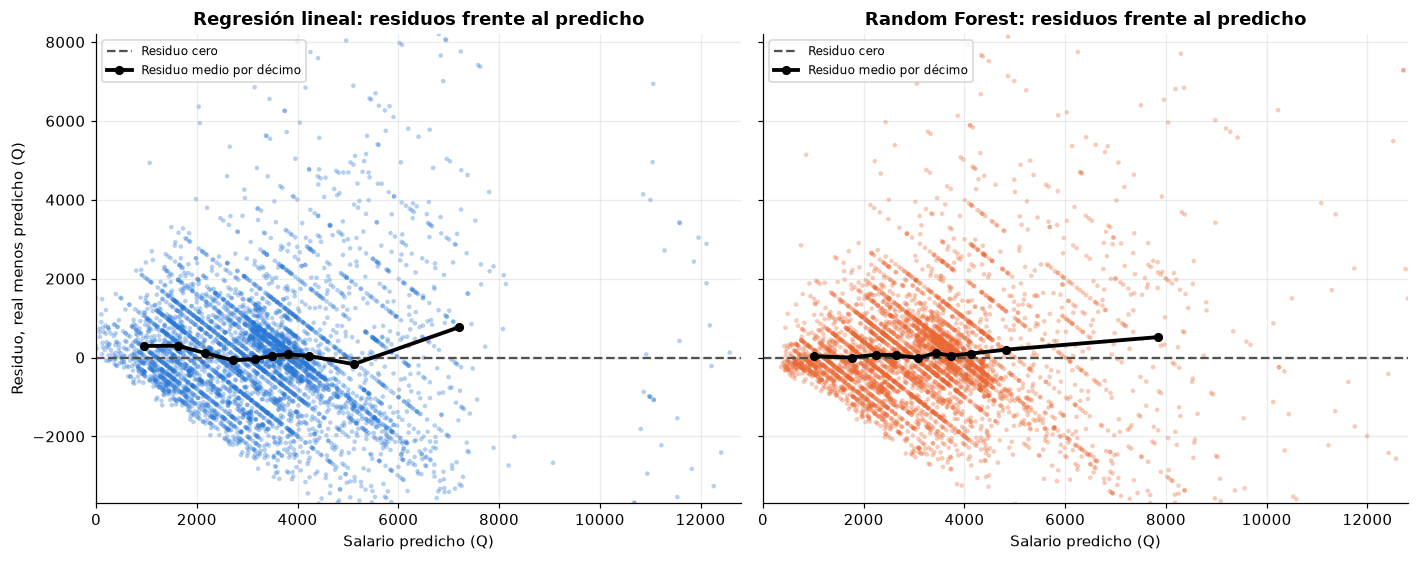

In [47]:
res_bajo = muestra[["res_lr", "res_rf"]].quantile(0.01).min()
res_alto = muestra[["res_lr", "res_rf"]].quantile(0.99).max()
tope_pred = muestra[["pred_lr", "pred_rf"]].quantile(0.995).max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
for ax, (nombre, pred, res, color) in zip(axes, MODELOS_GRAFICA):
    ax.scatter(muestra[pred], muestra[res], s=9, alpha=0.35, color=color, edgecolors="none")
    ax.axhline(0, color="#52514e", ls="--", lw=1.5, label="Residuo cero")
    tendencia = (muestra.assign(tramo=pd.qcut(muestra[pred], 10, duplicates="drop"))
                 .groupby("tramo", observed=True).agg(x=(pred, "mean"), y=(res, "mean")))
    ax.plot(tendencia["x"], tendencia["y"], color="black", lw=2.5, marker="o", ms=5, label="Residuo medio por décimo")
    ax.set_xlim(piso_pred, tope_pred)
    ax.set_ylim(res_bajo, res_alto)
    ax.set_title(f"{nombre}: residuos frente al predicho")
    ax.set_xlabel("Salario predicho (Q)")
    ax.legend(loc="upper left", fontsize=8)
    fuera = ((muestra[res] < res_bajo) | (muestra[res] > res_alto)).sum()
    print(f"{nombre}: {fuera} de {len(muestra):,} puntos de la muestra quedan fuera del recorte vertical")
axes[0].set_ylabel("Residuo, real menos predicho (Q)")
fig.tight_layout()
plt.show()

Con residuo positivo el modelo subestimó y con residuo negativo sobreestimó. En los dos modelos la línea gruesa se mantiene cerca de cero hasta predicciones de unos Q5,000 y sube hacia la derecha. Cuando el modelo predice un salario alto, el salario real suele ser todavía mayor. Es la señal de un modelo que comprime el rango de salarios y predice valores más cercanos al promedio que los reales.

La nube tiene forma de diagonales descendentes. Cada diagonal corresponde a un mismo salario real, un monto redondo. Como el residuo es real menos predicho, dentro de una diagonal el residuo baja al subir la predicción. Los puntos con residuos muy positivos, arriba, son personas con salarios altos que ninguno de los seis predictores explica, y son los que más pesan en el RMSE. La nube es asimétrica, con cola hacia arriba, igual que la distribución del salario. Los residuos negativos tienen un límite natural porque el salario real no puede bajar de cero.

### 8.3 Errores según el percentil del salario

Para ver si los errores dependen de qué tan alto es el salario, se ordenan los registros de prueba por salario real y se agrupan en bandas de percentil. Se usan bandas de diez puntos y el último décimo se divide en tres tramos, P90 a P95, P95 a P99 y P99 a P100, para mirar la cola derecha con más detalle. Los percentiles se asignan con `percent_rank` sobre todos los registros de prueba. Los salarios repetidos comparten rango y caen en la misma banda, por eso el número de registros de cada banda no es exactamente el nominal. Esta división usa el salario real, que es lo que se quiere explicar, y solo sirve para diagnosticar los errores. Ningún modelo la usa.

Primero, la distribución del salario real y de las predicciones, en percentiles.

In [48]:
niveles = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
lista_niveles = ", ".join(str(q) for q in niveles)
fila_pct = err26.agg(*[
    F.expr(f"percentile({c}, array({lista_niveles}))").alias(c) for c in [OBJETIVO, "pred_lr", "pred_rf"]
]).first()
distribucion = pd.DataFrame({
    "Salario real": fila_pct[OBJETIVO],
    "Predicción regresión lineal": fila_pct["pred_lr"],
    "Predicción Random Forest": fila_pct["pred_rf"],
}, index=[f"P{round(100 * q)}" for q in niveles])
print("Percentiles del salario real y de las predicciones en 2026T1, en quetzales")
display(distribucion)

Percentiles del salario real y de las predicciones en 2026T1, en quetzales


,Salario real,Predicción regresión lineal,Predicción Random Forest
P5,720.00,"1,095.43","1,054.47"
P25,"2,000.00","2,178.10","2,205.76"
P50,"3,200.00","3,282.51","3,222.62"
P75,"4,080.00","4,211.67","4,115.82"
P90,"6,000.00","5,678.29","5,807.89"
P95,"8,000.00","6,425.77","6,991.06"
P99,"15,000.00","11,018.15","11,039.45"


Errores por banda de percentil del salario real, con todos los registros de prueba


,n,salario_min,salario_max,MAE_lineal,error_medio_lineal,MAE_rf,error_medio_rf,pct_subestima_lineal,pct_subestima_rf
banda,,,,,,,,,
P0-10,1486,100.00,"1,000.00","1,070.49",-987.07,835.68,-812.16,13.53,7.13
P10-20,1383,"1,008.00","1,600.00",933.67,-770.92,795.60,-682.24,21.84,20.75
P20-30,1163,"1,620.00","2,000.00",983.22,-695.16,805.23,-622.33,30.35,25.71
P30-40,1523,"2,010.00","2,800.00",863.24,-257.50,662.47,-230.46,45.31,44.71
P40-50,1192,"2,850.00","3,200.00",836.90,-37.90,680.85,-16.93,50.00,50.92
P50-60,1249,"3,205.00","3,700.00",844.78,-112.47,720.95,-88.36,50.52,52.20
P60-70,1876,"3,720.00","4,000.00",817.11,-43.41,759.83,-10.91,58.26,59.01
P70-80,910,"4,002.00","4,500.00",904.94,128.66,811.84,169.78,65.16,67.03
P80-90,1225,"4,520.00","6,000.00","1,369.15",700.65,"1,409.54",643.06,71.43,73.39


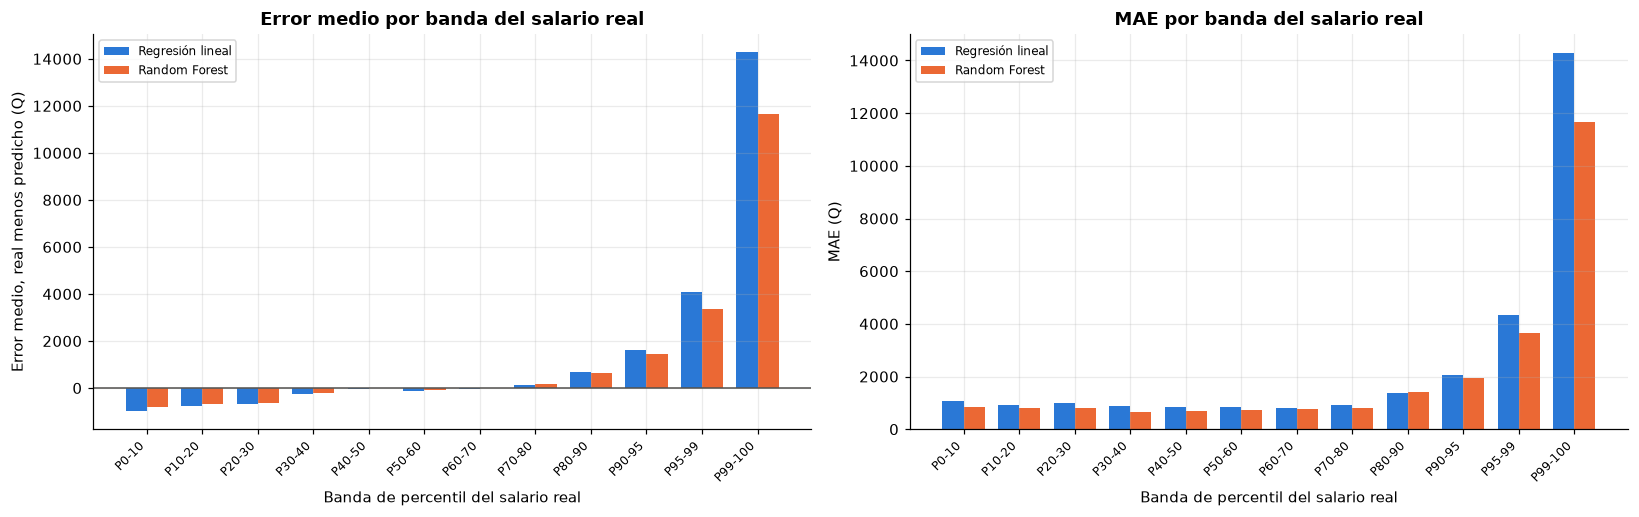

Error medio con signo en distintas zonas de la distribución


,n,error_medio_lineal,error_medio_rf
Décimo inferior (P0-10),1486,-987.07,-812.16
Mitad central (P30-70),5840,-112.89,-85.96
Décimo superior (P90-100),1251,"3,695.92","3,076.41"
Cola extrema (P99-100),98,"14,285.38","11,663.30"
Todos los registros,13258,120.55,106.70


In [49]:
from pyspark.ml.feature import Bucketizer

BORDES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99, 1.0001]
ETIQUETAS_BANDA = ["P0-10", "P10-20", "P20-30", "P30-40", "P40-50", "P50-60", "P60-70", "P70-80",
                   "P80-90", "P90-95", "P95-99", "P99-100"]

con_rango = err26.withColumn("rango_pct", F.percent_rank().over(Window.orderBy(OBJETIVO)))
con_banda = Bucketizer(splits=BORDES, inputCol="rango_pct", outputCol="banda").transform(con_rango).cache()

por_banda = (con_banda.groupBy("banda").agg(
    F.count("*").alias("n"),
    F.min(OBJETIVO).alias("salario_min"),
    F.max(OBJETIVO).alias("salario_max"),
    F.mean(F.abs("res_lr")).alias("MAE_lineal"),
    F.mean("res_lr").alias("error_medio_lineal"),
    F.mean(F.abs("res_rf")).alias("MAE_rf"),
    F.mean("res_rf").alias("error_medio_rf"),
    (100 * F.mean((F.col("res_lr") > 0).cast("double"))).alias("pct_subestima_lineal"),
    (100 * F.mean((F.col("res_rf") > 0).cast("double"))).alias("pct_subestima_rf"),
).orderBy("banda").toPandas())
por_banda["banda"] = [ETIQUETAS_BANDA[int(b)] for b in por_banda["banda"]]
por_banda = por_banda.set_index("banda")
print("Errores por banda de percentil del salario real, con todos los registros de prueba")
display(por_banda)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
x = np.arange(len(por_banda))
ancho = 0.38
axes[0].bar(x - ancho / 2, por_banda["error_medio_lineal"], ancho, color=AZUL, label="Regresión lineal")
axes[0].bar(x + ancho / 2, por_banda["error_medio_rf"], ancho, color=NARANJA, label="Random Forest")
axes[0].axhline(0, color="#52514e", lw=1)
axes[0].set_title("Error medio por banda del salario real")
axes[0].set_ylabel("Error medio, real menos predicho (Q)")
axes[1].bar(x - ancho / 2, por_banda["MAE_lineal"], ancho, color=AZUL, label="Regresión lineal")
axes[1].bar(x + ancho / 2, por_banda["MAE_rf"], ancho, color=NARANJA, label="Random Forest")
axes[1].set_title("MAE por banda del salario real")
axes[1].set_ylabel("MAE (Q)")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(por_banda.index, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Banda de percentil del salario real")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Sesgo en los extremos de la distribución
extremos = {
    "Décimo inferior (P0-10)": con_banda.filter(F.col("banda") == 0),
    "Mitad central (P30-70)": con_banda.filter(F.col("banda").between(3, 6)),
    "Décimo superior (P90-100)": con_banda.filter(F.col("banda") >= 9),
    "Cola extrema (P99-100)": con_banda.filter(F.col("banda") == 11),
    "Todos los registros": con_banda,
}
sesgo = pd.DataFrame({
    nombre: {"n": df.count(), "error_medio_lineal": df.agg(F.mean("res_lr")).first()[0],
             "error_medio_rf": df.agg(F.mean("res_rf")).first()[0]}
    for nombre, df in extremos.items()
}).T
sesgo["n"] = sesgo["n"].astype(int)
print("Error medio con signo en distintas zonas de la distribución")
display(sesgo)

La tabla y las barras responden si los errores dependen del nivel de salario. Hay dos formas de leerlas.

**Error medio con signo.** Si en las bandas altas el error medio es positivo y grande, el modelo subestima a quienes más ganan. Si en las bandas bajas es negativo, sobreestima a quienes menos ganan. Los dos modelos aprenden un promedio condicional al perfil. Un promedio queda por encima de los salarios más bajos y por debajo de los más altos dentro de cada perfil, así que la combinación de subestimación arriba y sobreestimación abajo es el resultado esperable, y la tabla de `sesgo` lo cuantifica. En el conjunto completo el error medio suele quedar cerca de cero porque los errores de las bandas altas y bajas se compensan. Un valor cercano a cero no indica que el modelo acierte, solo que no hay un sesgo global.

**MAE por banda.** Se espera que el MAE crezca hacia las bandas altas, porque el salario tiene cola derecha y las distancias en quetzales son mayores donde los salarios son mayores. También es algo mayor en el décimo inferior que en la zona central, Q1,070 frente a Q837 con la regresión lineal. En la cola extrema, P99 a P100, el error suele ser varias veces el de la mitad de la distribución. La celda de resumen de 8.5 imprime esa razón. Esos pocos registros explican por qué el RMSE supera con holgura al MAE, como se anticipó en 5.6.

**Porcentaje de subestimación.** La columna `pct_subestima_*` da la proporción de registros de cada banda con residuo positivo. Cerca de 100 % en las bandas altas y cerca de 0 % en las bajas confirma el patrón de compresión hacia el promedio. En la banda central se espera un valor cercano a 50 %.

**Comparación entre modelos.** El Random Forest puede seguir mejor a las bandas intermedias porque captura interacciones entre variables. Es esperable que ninguno alcance a los salarios más altos con estos seis predictores, y que la diferencia entre ellos en la cola extrema sea pequeña frente al tamaño del error en esa zona. Los extremos del salario dependen de factores que no están en las variables, como la ocupación concreta, el sector o el tamaño de la empresa.

Los salarios altos no se eliminaron ni se recortaron, como pide el enunciado. Se mantienen en la evaluación y se ven aquí como la principal fuente de error. Sacarlos reduciría el RMSE, pero el resultado dejaría de describir a los asalariados de la prueba.

### 8.4 Errores por nivel educativo y por dominio

Las tablas calculan, para cada grupo y con todos los registros de prueba, el número de observaciones, el salario mediano, y el MAE y el error medio de cada modelo. El MAE mide el tamaño típico del error. El error medio con signo indica si el modelo tiende a subestimar, con valor positivo, o a sobreestimar, con valor negativo, dentro del grupo. Los grupos con pocas observaciones dan cifras inestables y se leen con cautela. La última fila de cada tabla es el conjunto completo de prueba y sirve de comparación.

In [50]:
def tabla_errores(df, etiqueta, cod):
    # El código solo se usa para ordenar los grupos como en el diccionario
    orden = df26.groupBy(etiqueta).agg(F.min(cod).alias("_orden"))
    agregados = [
        F.count("*").alias("n"),
        F.expr(f"percentile({OBJETIVO}, 0.5)").alias("salario_mediano"),
        F.mean(F.abs("res_lr")).alias("MAE_lineal"),
        F.mean("res_lr").alias("error_medio_lineal"),
        F.mean(F.abs("res_rf")).alias("MAE_rf"),
        F.mean("res_rf").alias("error_medio_rf"),
    ]
    por_grupo = (df.groupBy(etiqueta).agg(*agregados)
                 .join(orden, etiqueta, "left")
                 .orderBy(F.col("_orden").asc_nulls_last()).drop("_orden")
                 .toPandas().set_index(etiqueta))
    total = df.agg(*agregados).toPandas().rename(index={0: "Todos los registros"})
    return pd.concat([por_grupo, total])


tabla_nivel = tabla_errores(err26, "nivel_educativo", "nivel_educativo_cod")
tabla_dominio = tabla_errores(err26, "dominio", "dominio_cod")
tabla_nivel["n"] = tabla_nivel["n"].astype(int)
tabla_dominio["n"] = tabla_dominio["n"].astype(int)

print("Errores por nivel educativo")
display(tabla_nivel)
print("Errores por dominio")
display(tabla_dominio)
assert tabla_nivel["n"].iloc[:-1].sum() == n_err and tabla_dominio["n"].iloc[:-1].sum() == n_err, \
    "Los grupos no suman los registros de prueba"

Errores por nivel educativo


,n,salario_mediano,MAE_lineal,error_medio_lineal,MAE_rf,error_medio_rf
Ninguno,1016,"1,680.00",823.51,109.34,622.21,49.28
Preprimaria,80,"2,400.00",735.21,88.76,552.98,45.28
Primaria,3957,"2,400.00",870.04,54.56,742.31,55.96
Básico,2164,"3,000.00",894.45,127.77,792.71,139.16
Diversificado,4117,"3,800.00","1,109.31",103.98,999.92,98.91
Superior,1729,"5,000.00","2,566.37",295.51,"2,211.38",246.99
Postgrado,183,"10,000.00","5,552.88",-131.50,"4,472.55",-288.32
DESCONOCIDO,12,"18,500.00","12,919.31","6,062.70","9,510.80","4,740.19"
Todos los registros,13258,"3,200.00","1,240.71",120.55,"1,071.19",106.70


Errores por dominio


,n,salario_mediano,MAE_lineal,error_medio_lineal,MAE_rf,error_medio_rf
Urbano metropolitano,5632,"3,900.00","1,446.09",136.04,"1,285.51",146.72
Resto urbano,4846,"3,000.00","1,189.65",134.28,"1,008.86",95.81
Rural nacional,2780,"2,160.00",913.64,65.24,745.66,44.61
Todos los registros,13258,"3,200.00","1,240.71",120.55,"1,071.19",106.70


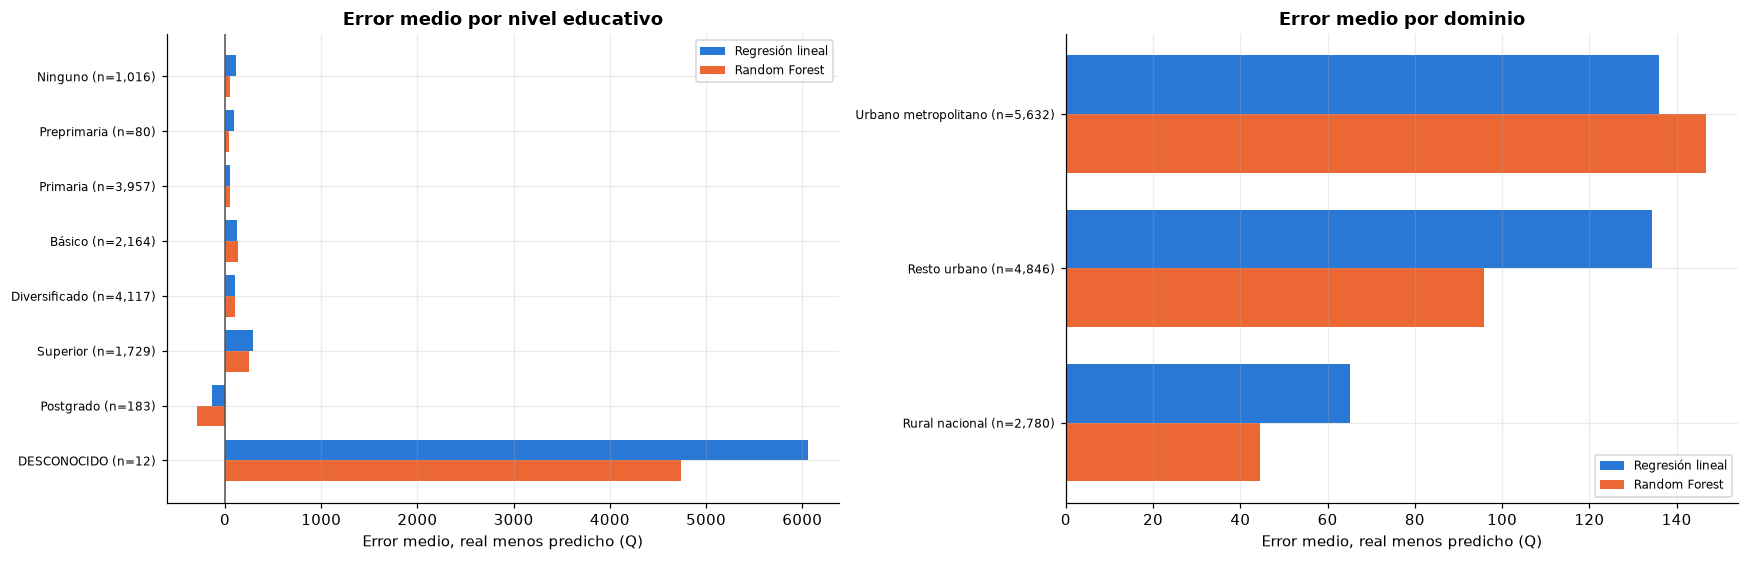

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
for ax, tabla, titulo in [(axes[0], tabla_nivel.iloc[:-1], "Nivel educativo"), (axes[1], tabla_dominio.iloc[:-1], "Dominio")]:
    y = np.arange(len(tabla))
    alto = 0.38
    ax.barh(y - alto / 2, tabla["error_medio_lineal"], alto, color=AZUL, label="Regresión lineal")
    ax.barh(y + alto / 2, tabla["error_medio_rf"], alto, color=NARANJA, label="Random Forest")
    ax.axvline(0, color="#52514e", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{g} (n={n:,})" for g, n in zip(tabla.index, tabla["n"])], fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"Error medio por {titulo.lower()}")
    ax.set_xlabel("Error medio, real menos predicho (Q)")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Las tablas permiten ver en qué grupos el modelo se equivoca más y en qué dirección.

**Nivel educativo.** El MAE crece con el nivel educativo porque los salarios son más altos y más dispersos. En Superior es de Q2,566 con la regresión lineal y Q2,211 con el Random Forest, y en Postgrado de Q5,553 y Q4,473, frente a Q824 y Q622 en Ninguno. El error medio es pequeño y positivo en casi todos los niveles, entre Q45 y Q296, es decir, una subestimación leve, y Superior es el nivel más subestimado. Postgrado es la excepción. Su error medio es negativo, -Q132 con la regresión lineal y -Q288 con el Random Forest, aunque su MAE es grande. En ese grupo los errores tienen signos mixtos y se compensan en el promedio. DESCONOCIDO tiene 12 registros y errores enormes, con un MAE de Q12,919 y Q9,511 y una subestimación media de Q6,063 y Q4,740. Con tan pocos registros no se puede concluir un patrón.

**Dominio.** El MAE es mayor donde el salario mediano es mayor. Urbano metropolitano, con mediana de Q3,900, tiene un MAE de Q1,446 con la regresión lineal y Q1,286 con el Random Forest. Resto urbano tiene Q1,190 y Q1,009. Rural nacional, con mediana de Q2,160, tiene Q914 y Q746. El error medio es positivo en los tres dominios, entre Q45 y Q147, sin diferencias grandes entre ellos. Los dominios tienen miles de registros y sus cifras son estables.

**Cómo leer el MAE frente al salario mediano.** En los grupos con más de 100 registros el MAE equivale a entre 26 % y 55 % del salario mediano del grupo, según el modelo. El error típico es entre un cuarto y la mitad del salario mismo, y proporcionalmente mayor en Superior, Postgrado y Ninguno. Estas predicciones sirven para ordenar perfiles y estimar el nivel general de un grupo, pero no para fijar un monto individual. El error medio global es positivo en ambos modelos, Q121 con la regresión lineal y Q107 con el Random Forest, y es pequeño frente al MAE. Puede reflejar que el salario de 2026 es algo mayor que el de los trimestres usados para entrenar.

### 8.5 Resumen de los resultados y discusión final

La celda siguiente reúne en una sola salida las cifras que se usan en la discusión. Se calculan a partir de los objetos ya creados en las secciones 7 y 8.

In [52]:
res_total = metricas_prueba.loc[modelos_finales, ["MAE", "RMSE", "R2"]]
print("Métricas en la prueba de 2026T1")
display(res_total)

print(f"Mejor algoritmo por RMSE en la prueba: {MEJOR_EN_PRUEBA}")
print(f"Mejor referencia constante: RMSE Q{base_rmse_prueba:,.0f}, MAE Q{base_mae_prueba:,.0f}")

alto_nivel = sesgo.loc["Décimo superior (P90-100)"]
bajo_nivel = sesgo.loc["Décimo inferior (P0-10)"]
for nombre, col in [("Regresión lineal", "error_medio_lineal"), ("Random Forest", "error_medio_rf")]:
    print(f"{nombre}: error medio Q{bajo_nivel[col]:,.0f} en el décimo inferior y Q{alto_nivel[col]:,.0f} en el décimo superior. "
          f"{'Subestima' if alto_nivel[col] > 0 else 'Sobreestima'} a los salarios altos y "
          f"{'sobreestima' if bajo_nivel[col] < 0 else 'subestima'} a los bajos")

cola = por_banda.loc["P99-100"]
centro = por_banda.loc[["P40-50", "P50-60"]]
for nombre, col in [("Regresión lineal", "MAE_lineal"), ("Random Forest", "MAE_rf")]:
    print(f"{nombre}: MAE en la cola P99-100 Q{cola[col]:,.0f}, {cola[col] / centro[col].mean():.1f} veces el de la zona central")

grupo_peor = tabla_nivel.iloc[:-1]
for nombre, col in [("Regresión lineal", "MAE_lineal"), ("Random Forest", "MAE_rf")]:
    g = grupo_peor[col].idxmax()
    print(f"{nombre}: mayor MAE por nivel educativo en {g}, Q{grupo_peor.loc[g, col]:,.0f}, con {grupo_peor.loc[g, 'n']:,} registros")

Métricas en la prueba de 2026T1


,MAE,RMSE,R2
modelo,,,
Regresión lineal lr1,"1,240.71","2,163.75",0.43
Random Forest rf4,"1,071.19","1,882.80",0.57


Mejor algoritmo por RMSE en la prueba: Random Forest rf4
Mejor referencia constante: RMSE Q2,871, MAE Q1,718
Regresión lineal: error medio Q-987 en el décimo inferior y Q3,696 en el décimo superior. Subestima a los salarios altos y sobreestima a los bajos
Random Forest: error medio Q-812 en el décimo inferior y Q3,076 en el décimo superior. Subestima a los salarios altos y sobreestima a los bajos
Regresión lineal: MAE en la cola P99-100 Q14,285, 17.0 veces el de la zona central
Random Forest: MAE en la cola P99-100 Q11,663, 16.6 veces el de la zona central
Regresión lineal: mayor MAE por nivel educativo en DESCONOCIDO, Q12,919, con 12 registros
Random Forest: mayor MAE por nivel educativo en DESCONOCIDO, Q9,511, con 12 registros


### 8.6 Discusión final

**Perfiles de trabajadores.** KMeans con K = 2 tuvo la mayor silueta entre las variantes sin salario, 0.55. Separa a los asalariados en dos perfiles. El primero reúne al 27.5 % de los registros. Son adultos mayores, con edad media de 51 años, antigüedad alta, 13.8 años en promedio, y jornada completa, 41 horas semanales. El segundo reúne al 72.5 %. Son jóvenes de 29 años, con poca antigüedad, 2.4 años en promedio, y jornada extendida, 48 horas. El primer grupo tiene un salario mediano mayor, Q3,468 frente a Q3,000, y más empleo de gobierno, 23.5 % frente a 8.2 %. Esto concuerda con la matriz de correlaciones. La edad y la antigüedad se asocian, con un coeficiente de 0.49, y el salario se asocia débilmente con la antigüedad, 0.18, la edad, 0.15, y las horas, 0.08. Ninguna variable numérica separa por sí sola a quienes ganan mucho de quienes ganan poco. El nivel educativo y la categoría ocupacional marcan diferencias mayores. El salario mediano va de Q1,500 en Ninguno a Q10,000 en Postgrado, y de Q1,000 en servicio doméstico a Q5,000 en empleo de gobierno.

**Qué tan bien se estima el salario.** En la prueba de 2026 la mejor referencia constante tiene un RMSE de Q2,871. La regresión lineal lo baja a Q2,164 y el Random Forest a Q1,883. El R² es de 0.43 y 0.57, así que los seis predictores explican menos de tres quintas partes de la variación del salario. El MAE del Random Forest, Q1,071, equivale a un tercio del salario mediano global, Q3,200. Los modelos sirven para describir cómo se asocian la educación, la categoría ocupacional, la antigüedad y las horas con el salario, y para comparar perfiles. No sirven para fijar el salario de una persona, como advierte el enunciado. Las asociaciones no son causales.

**Regresión lineal frente a Random Forest.** El Random Forest gana tanto en validación como en prueba. Su RMSE de prueba es 13 % menor, Q1,883 frente a Q2,164, y la ventaja es del mismo tamaño en validación, Q1,896 frente a Q2,186, así que no depende del trimestre. Es coherente con relaciones no lineales e interacciones que la regresión lineal no representa. El bosque asigna importancia a la edad, las horas y la antigüedad junto con los niveles Postgrado y Superior. La regresión lineal es más simple y sus coeficientes se interpretan, pero produce predicciones negativas en algunos casos. Su regularización casi no cambió los resultados, con un RMSE de validación entre Q2,186.4 y Q2,186.6 en las seis configuraciones. El Random Forest elegido es el más profundo de la malla, con `maxDepth` de 15. Su error de entrenamiento, Q1,733, es menor que el de validación, Q1,896. Hay algo de sobreajuste, aunque no llegó a empeorar la validación.

**Dónde se equivocan.** El error no se reparte por igual entre los niveles de salario. En el décimo superior de salarios reales el error medio es de +Q3,696 con la regresión lineal y +Q3,076 con el Random Forest, es decir, subestiman. En el décimo inferior es de -Q987 y -Q812, es decir, sobreestiman. En la mitad central es de -Q113 y -Q86. Entre el 84 % y el 100 % de los registros por encima del percentil 90 quedan subestimados, y el 100 % en el 1 % superior. Los dos modelos predicen un percentil 99 de unos Q11,000 cuando el real es de Q15,000. El MAE del 1 % superior es de Q14,285 y Q11,663, unas 17 veces el de la zona central. Esos pocos registros explican por qué el RMSE es cercano a 1.75 veces el MAE. El patrón se repite por grupo. El MAE crece con el nivel educativo y es mayor en el dominio metropolitano, donde los salarios son más altos, y Superior es el nivel más subestimado. El error medio global es positivo pero pequeño, Q121 y Q107, y es la suma de subestimación en los salarios altos y sobreestimación en los bajos.

**Limitaciones.**
- Faltan variables que determinan el salario, como la ocupación específica, el sector de actividad, el tamaño de la empresa y la región. Sin ellas hay un techo en el R² que ningún algoritmo supera.
- Las métricas, el clustering y los modelos no están ponderados con `FACTOR`. Los resultados describen a los registros analizados y no son estimaciones oficiales de la población guatemalteca. Un análisis poblacional pesaría cada registro con su factor de expansión.
- La prueba es un solo trimestre, y la encuesta tiene rotación, así que una misma persona puede aparecer en 2025 y en 2026. Una diferencia pequeña entre modelos en un solo trimestre no permite concluir que uno sea mejor en general.
- La mejor configuración de Random Forest está en el borde de la malla probada, `maxDepth` de 15, y el RMSE de validación seguía bajando al aumentar la profundidad. Una malla más amplia podría mejorarla, a costa de más tiempo de cómputo y más sobreajuste.
- Se trabajó con el salario en quetzales sin transformarlo, como pide la comparación obligatoria. Modelar el logaritmo del salario o usar una pérdida menos sensible a los extremos podría reducir la subestimación en la cola, aunque cambiaría la métrica que se optimiza.
- La segmentación con K = 2 es muy gruesa. Separa sobre todo por edad y antigüedad, y no distingue perfiles más finos por horas o por categoría ocupacional.

**Siguientes pasos posibles.** Agregar variables de ocupación o sector si estuvieran disponibles, modelar el logaritmo del salario, ampliar la malla del Random Forest, probar un modelo que dé intervalos de predicción para reflejar la incertidumbre, y ponderar con `FACTOR` si el objetivo pasa a ser una estimación poblacional.